<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC680 - Applied Data Science

## **Name:** Tim Hollis

## **Assignment:** Networking in Data Science: Kaggle Competition

## **Date:** October 11, 2026

---

**Reference**

Healey, D., Krettler, C., Kind, T., Killian, M., Drake, S., DeBloois, E., Lightheart, I., Gadiya, Y., Simpson, P., Domingo-Fernandez, D., Colluru, V., Allen, A., Reade, W., & Oldacre, A. (2026). *Enveda CASMI 2026: Molecule ID from mass spectra* [Data set]. Kaggle. https://www.kaggle.com/competitions/enveda-CASMI26-molecule-id-mass-spectra

</div>

### **Initial Setup**

In [73]:
# Development-only provisioning. RDKit is absent from the Kaggle base image and is used
# here to verify the competition metric against known answers. It is not needed to produce
# a submission, so this cell is expected to fail harmlessly during the internet-disabled
# rerun, after which the notebook skips the validation sections.
!pip install -q --retries 0 --timeout 5 rdkit==2026.03.3

In [74]:
import os
import glob
import re
import shutil
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST_GREEN = '#228B22'
AMBER = '#E69F00'
LIGHT_GRAY = '#D3D3D3'
DARK_GRAY = '#4D4D4D'
PALETTE = [ROYAL_BLUE, PURPLE, FOREST_GREEN, AMBER, DARK_GRAY, LIGHT_GRAY]

MAX_ANCHORS = 10
print('✅ Anchor Max set')

RANDOM_STATE = 42
PPM_TOLERANCE = 15.0
TOP_K = 25
print('✅ Random state and tolerance set')

LIBRARY_CONFIDENT = 0.95
print(f'🎚️ Library confidence gate set to {LIBRARY_CONFIDENT:,.2f}')

PROTON_MASS = 1.00727646
ELECTRON_MASS = 0.00054858

TEST_ADDUCTS = [
    '[M+H]+', '[M+NH4]+', '[M-H2O+H]+', '[M-2H2O+H]+', '[M+Na]+',
    '[M+K]+', '[M-H]-', '[M-H2O-H]-', '[M+CH2O2-H]-', '[M+Cl]-',
]

INSTRUMENT_MATCHED_LIBS = ['enveda-180', 'enveda-np-examples']
NATURAL_PRODUCT_LIBS = ['gnps', 'riken', 'massbank', 'mona', 'spectraverse', 'msdial']
VALIDATION_LIB = 'enveda-np-examples'

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': LIGHT_GRAY,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.frameon': False,
})

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

train_matches = sorted(INPUT_ROOT.rglob('train.parquet'))
if not train_matches:
    attached = sorted(p.name for p in INPUT_ROOT.iterdir()) if INPUT_ROOT.exists() else []
    raise FileNotFoundError(
        f'train.parquet not found under {INPUT_ROOT}. Attached inputs: {attached}. '
        'Attach the competition under Input, then restart the session.'
    )

COMP_DIR = train_matches[0].parent
TRAIN_PATH = COMP_DIR / 'train.parquet'
TEST_PATH = COMP_DIR / 'test.parquet'
SAMPLE_SUB_PATH = COMP_DIR / 'sample_submission.csv'

def cache_path(filename):
    '''Prefer a cached artifact attached as a Kaggle input, falling back to the working directory.'''
    matches = sorted(INPUT_ROOT.rglob(filename))
    return matches[0] if matches else (WORK_DIR / filename)

def mirror_to_working(path):
    '''Copy a cache loaded from a read-only input into the working directory, so every
    committed version carries the caches forward in its own output.'''
    if path.parent == WORK_DIR:
        return path
    destination = WORK_DIR / path.name
    if not destination.exists():
        shutil.copyfile(path, destination)
    return destination

try:
    import rdkit
    from rdkit import Chem, RDLogger
    from rdkit.Chem import Descriptors, inchi, rdFingerprintGenerator
    from rdkit.Chem.MolStandardize import rdMolStandardize
    RDLogger.DisableLog('rdApp.*')
    RDKIT_VERSION = rdkit.__version__
except ImportError:
    RDKIT_VERSION = None

RDKIT_AVAILABLE = RDKIT_VERSION is not None

test_df = pd.read_parquet(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

train_file = pq.ParquetFile(TRAIN_PATH)
TRAIN_ROWS = train_file.metadata.num_rows
TRAIN_COLUMNS = [field.name for field in train_file.schema_arrow]


def load_train(columns=None, libraries=None):
    '''Read train.parquet selectively so the full file never lands in memory at once.'''
    filters = [('ingest_lib', 'in', list(libraries))] if libraries else None
    return pd.read_parquet(TRAIN_PATH, columns=columns, filters=filters)


n_test_molecules = test_df['molecule_id'].nunique()
n_test_adducts = test_df['adduct'].nunique()
rdkit_status = RDKIT_VERSION if RDKIT_VERSION else 'NOT AVAILABLE'

print('🚀 Environment initialized')
print(f'   numpy {np.__version__} | pandas {pd.__version__} | rdkit {rdkit_status}')
print(f'📂 Competition data mounted at {COMP_DIR.name}')
print(f'🧪 Test set: {len(test_df):,} spectra | {n_test_molecules:,} molecules | {n_test_adducts:,} adducts')
print(f'📚 Train set: {TRAIN_ROWS:,} spectra | {len(TRAIN_COLUMNS):,} columns, loaded on demand')
print(f'📄 Sample submission: {len(sample_sub):,} rows | columns {list(sample_sub.columns)}')
print(f'🎯 Scoring: MRR@{TOP_K} on InChIKey14 match')

✅ Anchor Max set
✅ Random state and tolerance set
🎚️ Library confidence gate set to 0.95
🚀 Environment initialized
   numpy 2.0.2 | pandas 2.3.3 | rdkit 2026.03.3
📂 Competition data mounted at enveda-CASMI26-molecule-id-mass-spectra
🧪 Test set: 1,213 spectra | 400 molecules | 7 adducts
📚 Train set: 2,539,608 spectra | 18 columns, loaded on demand
📄 Sample submission: 400 rows | columns ['molecule_id', 'smiles']
🎯 Scoring: MRR@25 on InChIKey14 match


### **Overview**

**The task.** Given the tandem mass spectra of an unknown molecule, predict its 2D chemical structure as a SMILES string. For each of the 400 test molecules I submit up to 25 candidate structures, ranked best guess first. A molecule may have been measured several times, at different collision energies or as different adducts, so predictions are made per molecule rather than per spectrum and the evidence from all of a molecule's spectra has to be aggregated into a single ranked list.

**What a spectrum is.** A mass spectrometer ionizes a molecule, measures the mass-to-charge ratio of the intact ion, then shatters that ion by collision with a neutral gas and records the mass and abundance of every fragment. The result is a list of fragment masses paired with intensities. The precursor mass constrains the molecular formula tightly. The fragment pattern carries the structural information, because which bonds break, and what the pieces weigh, depends on how the molecule is put together.

**Why this is hard.** Established methods identify a spectrum by matching it against a reference library of previously measured compounds. That works when the molecule has been measured before and fails completely when it has not. Every scored molecule here falls into one of three novelty classes, and which class a molecule belongs to is hidden for the duration of the competition. Class 1 molecules have public reference spectra and are reachable by spectral similarity. Class 2 molecules have no public spectra, but their structures exist in PubChem or the natural products database COCONUT, so they are reachable only by predicting the molecular formula and retrieving candidate structures from a database. Class 3 molecules are not in PubChem at all and must be constructed from scratch. A library search, by construction, scores zero on classes 2 and 3.

**How it is scored.** Mean reciprocal rank at 25. A correct structure in position 1 scores 1.0, position 2 scores 0.5, position 25 scores 0.04, and a molecule with no correct guess in the list scores 0. Correctness is judged on atom connectivity only, after tautomer canonicalization and reduction to the first block of the InChIKey, so stereochemistry and tautomer form do not count against a prediction. There is no penalty for a wrong guess beyond the rank it occupies, which makes the allocation of all 25 slots a decision in its own right.

**The central constraint in the training data.** The 2.5 million training spectra come from eleven source libraries, and the two properties that matter most are in conflict. The largest library, enveda-180, was acquired on the same Bruker timsTOF as the test set, but its chemistry is synthetic drug-like screening compounds, a different region of chemical space from the natural products being tested. The libraries that do contain natural product chemistry, chiefly GNPS and RIKEN, were collected across many instruments under inconsistent protocols. Instrument match and chemistry match cannot both be satisfied, and how that tradeoff is resolved is the main modeling decision in this notebook.

### **Section 1: Profiling the test set**

The test set is small enough to characterize completely, and three of its properties directly constrain the design of the retrieval pipeline.

1. Count the spectra belonging to each molecule, since predictions are scored per molecule and the evidence from several spectra has to be fused into one ranked list.
2. Tabulate the adducts and ionization modes present, since the adduct determines how the measured precursor mass maps back to the neutral molecular mass.
3. Describe the precursor m/z range, which bounds the size of the molecules in play.
4. Describe the fragment peak counts, which bound how much structural evidence each spectrum actually carries.

🔬 Test set profile
   Molecules: 400 across 1,213 spectra
   Spectra per molecule: min 1 | median 3 | max 9
   Precursor m/z: 245.1 to 460.2 | median 329.2
   Fragment peaks: min 4 | median 230 | max 3,259
   Adducts present: 7 of 10 possible
   Ionization mode: positive 987, negative 226


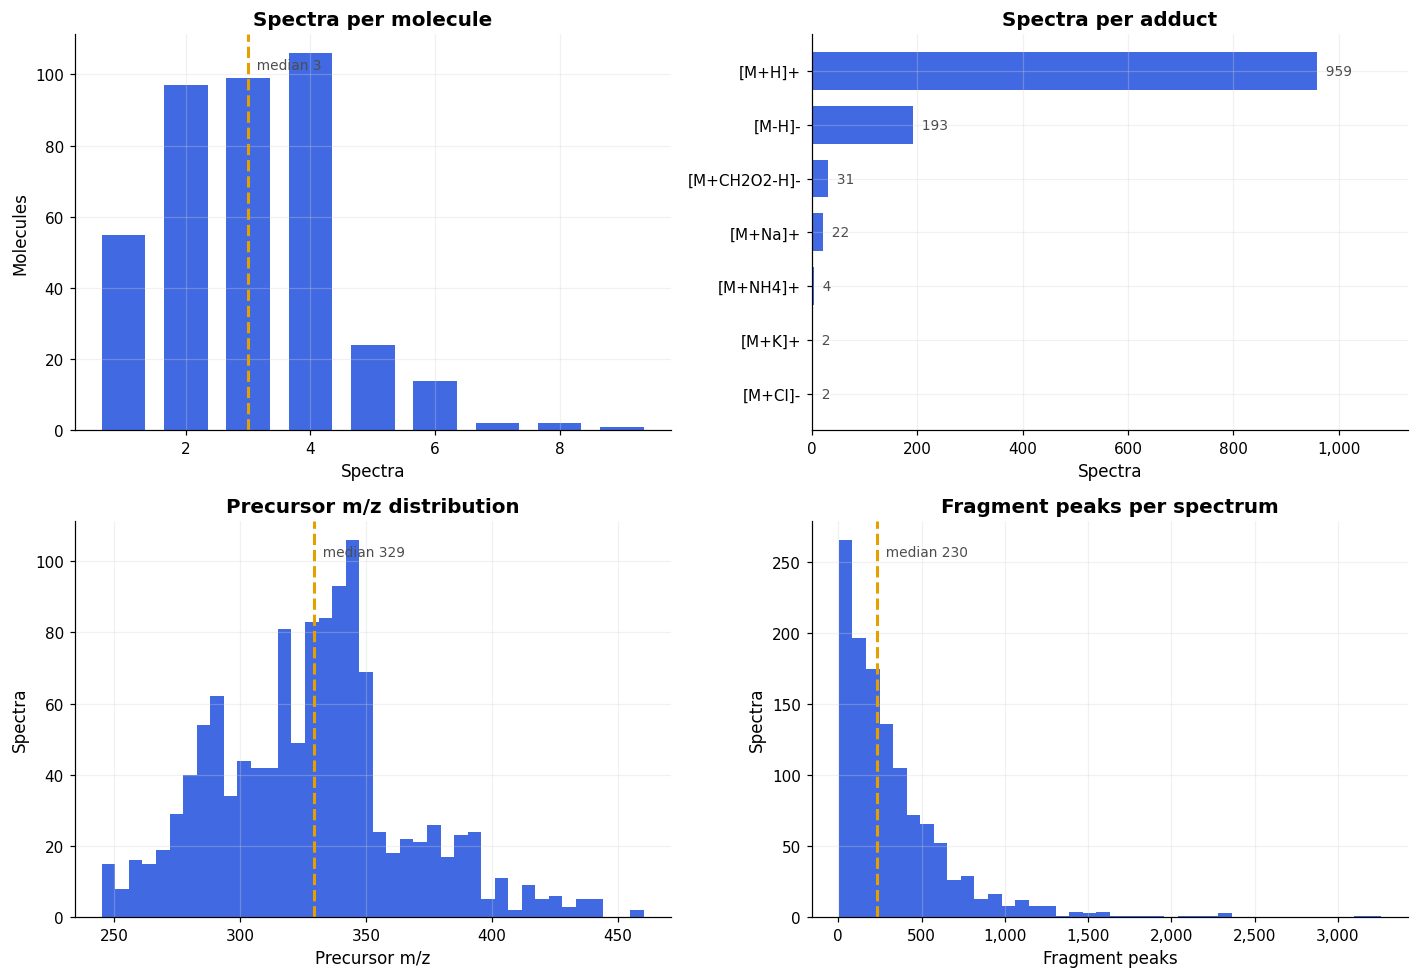

In [75]:
test_df['n_peaks'] = test_df['ms2_mzs'].apply(len)

spectra_per_molecule = test_df.groupby('molecule_id').size()
adduct_counts = test_df['adduct'].value_counts()
mode_counts = test_df['ionization_mode'].value_counts()

n_molecules = spectra_per_molecule.size
spm_min = int(spectra_per_molecule.min())
spm_max = int(spectra_per_molecule.max())
spm_median = float(spectra_per_molecule.median())
mz_min = float(test_df['precursor_mz'].min())
mz_max = float(test_df['precursor_mz'].max())
mz_median = float(test_df['precursor_mz'].median())
peak_min = int(test_df['n_peaks'].min())
peak_max = int(test_df['n_peaks'].max())
peak_median = float(test_df['n_peaks'].median())
mode_summary = ', '.join(f'{mode} {count:,}' for mode, count in mode_counts.items())

print('🔬 Test set profile')
print(f'   Molecules: {n_molecules:,} across {len(test_df):,} spectra')
print(f'   Spectra per molecule: min {spm_min:,} | median {spm_median:,.0f} | max {spm_max:,}')
print(f'   Precursor m/z: {mz_min:,.1f} to {mz_max:,.1f} | median {mz_median:,.1f}')
print(f'   Fragment peaks: min {peak_min:,} | median {peak_median:,.0f} | max {peak_max:,}')
print(f'   Adducts present: {len(adduct_counts):,} of {len(TEST_ADDUCTS):,} possible')
print(f'   Ionization mode: {mode_summary}')

comma_fmt = mpl.ticker.FuncFormatter(lambda value, _: f'{value:,.0f}')
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
spm_counts = spectra_per_molecule.value_counts().sort_index()
ax.bar(spm_counts.index, spm_counts.values, color=ROYAL_BLUE, width=0.7)
ax.axvline(spm_median, color=AMBER, linestyle='--', linewidth=2)
ax.text(spm_median, ax.get_ylim()[1] * 0.94, f'  median {spm_median:,.0f}',
        color=DARK_GRAY, fontsize=9, va='top')
ax.set_title('Spectra per molecule')
ax.set_xlabel('Spectra')
ax.set_ylabel('Molecules')
ax.yaxis.set_major_formatter(comma_fmt)

ax = axes[0, 1]
adducts_sorted = adduct_counts.sort_values()
ax.barh(adducts_sorted.index, adducts_sorted.values, color=ROYAL_BLUE, height=0.7)
for position, value in enumerate(adducts_sorted.values):
    ax.text(value, position, f'  {value:,}', va='center', fontsize=9, color=DARK_GRAY)
ax.set_xlim(0, adducts_sorted.max() * 1.18)
ax.set_title('Spectra per adduct')
ax.set_xlabel('Spectra')
ax.xaxis.set_major_formatter(comma_fmt)

ax = axes[1, 0]
ax.hist(test_df['precursor_mz'], bins=40, color=ROYAL_BLUE)
ax.axvline(mz_median, color=AMBER, linestyle='--', linewidth=2)
ax.text(mz_median, ax.get_ylim()[1] * 0.94, f'  median {mz_median:,.0f}',
        color=DARK_GRAY, fontsize=9, va='top')
ax.set_title('Precursor m/z distribution')
ax.set_xlabel('Precursor m/z')
ax.set_ylabel('Spectra')
ax.xaxis.set_major_formatter(comma_fmt)
ax.yaxis.set_major_formatter(comma_fmt)

ax = axes[1, 1]
ax.hist(test_df['n_peaks'], bins=40, color=ROYAL_BLUE)
ax.axvline(peak_median, color=AMBER, linestyle='--', linewidth=2)
ax.text(peak_median, ax.get_ylim()[1] * 0.94, f'  median {peak_median:,.0f}',
        color=DARK_GRAY, fontsize=9, va='top')
ax.set_title('Fragment peaks per spectrum')
ax.set_xlabel('Fragment peaks')
ax.set_ylabel('Spectra')
ax.xaxis.set_major_formatter(comma_fmt)
ax.yaxis.set_major_formatter(comma_fmt)

plt.tight_layout()
plt.show()

### **Section 2: Composition of the training libraries**

The 2.5 million training spectra are an aggregation of eleven source libraries, and they are not interchangeable. This section establishes which libraries are worth trusting for which purpose, and quantifies the conflict between instrument match and chemistry match described in the overview.

1. Load only the columns needed for composition, since the full file does not fit comfortably in memory.
2. Count spectra and distinct structures per source library.
3. Compare the fragment peak counts of each library against the test set median, since a similarity score computed between differently preprocessed spectra is not measuring what it appears to measure.
4. Summarize precursor mass error per library, which the competition ships uncleaned and which therefore doubles as a label quality signal.

📚 Training library composition
   Spectra: 2,539,608 | distinct structures: 275,810
   Validation library enveda-np-examples: 1,184 spectra, 250 structures
   Test set median peaks for comparison: 230

                    spectra  structures  median_peaks  median_abs_ppm
ingest_lib                                                           
enveda-180          1153785      182941      138.0000          0.9811
pluskal_ms2          527581       46821       21.0000          1.6638
riken                347171       15892        9.0000          3.7526
gnps                 220849       45750       46.0000          1.6734
massbank             101727        9180       11.0000          1.9485
mona                  92416       11681       57.0000          1.7994
spectraverse          50933        9631       47.0000          0.6504
msdial                40765        9127       11.0000          1.4702
drug_plus              2545        2539      108.0000          1.7336
enveda-np-examples     1184 

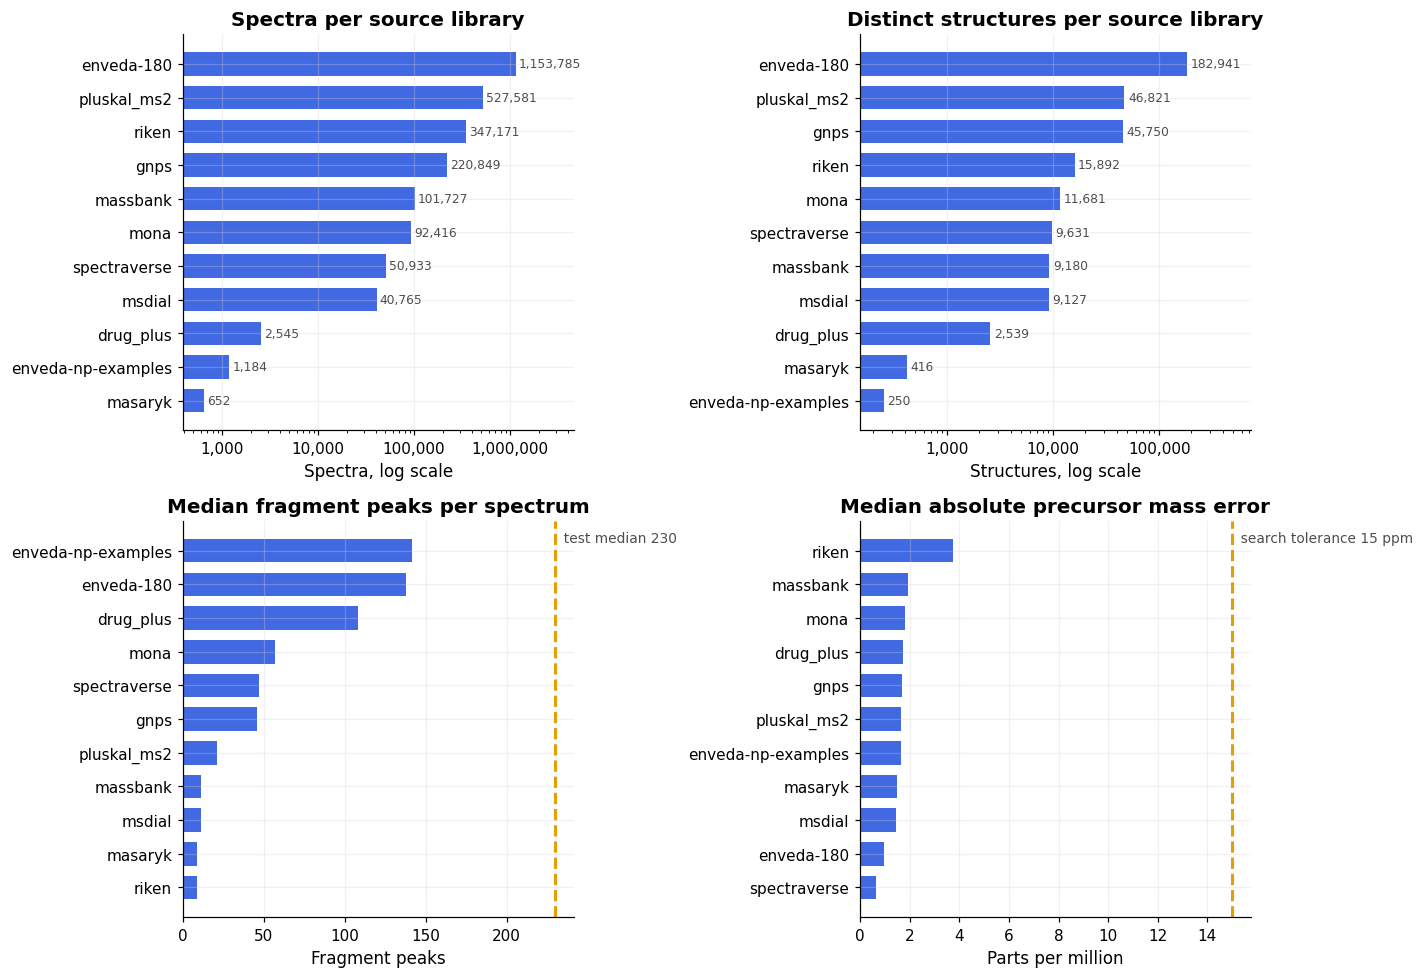

In [76]:
lib_df = load_train(columns=['ingest_lib', 'inchikey14', 'num_peaks', 'precursor_error_ppm'])

lib_stats = lib_df.groupby('ingest_lib').agg(
    spectra=('inchikey14', 'size'),
    structures=('inchikey14', 'nunique'),
    median_peaks=('num_peaks', 'median'),
    median_abs_ppm=('precursor_error_ppm', lambda s: s.abs().median()),
).sort_values('spectra', ascending=False)

total_structures = lib_df['inchikey14'].nunique()
validation_rows = int(lib_stats.loc[VALIDATION_LIB, 'spectra'])
validation_structures = int(lib_stats.loc[VALIDATION_LIB, 'structures'])

print('📚 Training library composition')
print(f'   Spectra: {len(lib_df):,} | distinct structures: {total_structures:,}')
print(f'   Validation library {VALIDATION_LIB}: {validation_rows:,} spectra, {validation_structures:,} structures')
print(f'   Test set median peaks for comparison: {peak_median:,.0f}')
print()
print(lib_stats)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ordered = lib_stats['spectra'].sort_values()
ax.barh(ordered.index, ordered.values, color=ROYAL_BLUE, height=0.7)
for position, value in enumerate(ordered.values):
    ax.text(value * 1.08, position, f'{value:,}', va='center', fontsize=8, color=DARK_GRAY)
ax.set_xscale('log')
ax.set_xlim(ordered.min() * 0.6, ordered.max() * 4)
ax.set_title('Spectra per source library')
ax.set_xlabel('Spectra, log scale')
ax.xaxis.set_major_formatter(comma_fmt)

ax = axes[0, 1]
ordered = lib_stats['structures'].sort_values()
ax.barh(ordered.index, ordered.values, color=ROYAL_BLUE, height=0.7)
for position, value in enumerate(ordered.values):
    ax.text(value * 1.08, position, f'{value:,}', va='center', fontsize=8, color=DARK_GRAY)
ax.set_xscale('log')
ax.set_xlim(ordered.min() * 0.6, ordered.max() * 4)
ax.set_title('Distinct structures per source library')
ax.set_xlabel('Structures, log scale')
ax.xaxis.set_major_formatter(comma_fmt)

ax = axes[1, 0]
ordered = lib_stats['median_peaks'].sort_values()
ax.barh(ordered.index, ordered.values, color=ROYAL_BLUE, height=0.7)
ax.axvline(peak_median, color=AMBER, linestyle='--', linewidth=2)
ax.text(peak_median, len(ordered) - 0.4, f'  test median {peak_median:,.0f}',
        color=DARK_GRAY, fontsize=9, va='top')
ax.set_title('Median fragment peaks per spectrum')
ax.set_xlabel('Fragment peaks')
ax.xaxis.set_major_formatter(comma_fmt)

ax = axes[1, 1]
ordered = lib_stats['median_abs_ppm'].sort_values()
ax.barh(ordered.index, ordered.values, color=ROYAL_BLUE, height=0.7)
ax.axvline(PPM_TOLERANCE, color=AMBER, linestyle='--', linewidth=2)
ax.text(PPM_TOLERANCE, len(ordered) - 0.4, f'  search tolerance {PPM_TOLERANCE:,.0f} ppm',
        color=DARK_GRAY, fontsize=9, va='top')
ax.set_title('Median absolute precursor mass error')
ax.set_xlabel('Parts per million')

plt.tight_layout()
plt.show()

### **Section 3: Implementing the competition metric**

Every design decision that follows needs to be measurable, so the scoring function comes before the pipeline rather than after it. The competition specifies exactly how a prediction is judged correct, and implementing that specification directly, rather than approximating it, means local results and leaderboard results measure the same thing.

1. Reduce a SMILES string to the competition's matching key by applying RDKit tautomer canonicalization and taking the first block of the InChIKey.
2. Verify the reduction against the worked example given in the competition rules, where two differently written forms of glucose must produce the same key.
3. Implement mean reciprocal rank at 25 and verify it against hand-calculable cases.
4. Build the validation target set from enveda-np-examples, the 250 natural products collected on the same instrument and pipeline as the test set.
5. Check whether tautomer canonicalization actually changes any key relative to the InChIKey14 column shipped in the training data, since the scorer canonicalizes and the shipped column does not.

In [77]:
_inchikey14_cache = {}
_tautomer_enumerator = None
if RDKIT_AVAILABLE:
    _tautomer_enumerator = rdMolStandardize.TautomerEnumerator()
    _tautomer_enumerator.SetMaxTautomers(1000)
    _tautomer_enumerator.SetMaxTransforms(1000)


def smiles_to_inchikey14(smiles):
    '''Reduce a SMILES to the key the competition compares: tautomer-canonical InChIKey14.
    Returns None when RDKit is unavailable or the structure cannot be parsed.'''
    if not RDKIT_AVAILABLE:
        return None
    if smiles in _inchikey14_cache:
        return _inchikey14_cache[smiles]
    key14 = None
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        try:
            full_key = inchi.MolToInchiKey(_tautomer_enumerator.Canonicalize(mol))
            if full_key:
                key14 = full_key.split('-')[0]
        except Exception:
            key14 = None
    _inchikey14_cache[smiles] = key14
    return key14


def reciprocal_rank(candidate_smiles, answer_key14, top_k=TOP_K):
    '''Position of the first correct candidate, reciprocated. Zero if absent from the top k.'''
    if answer_key14 is None:
        return 0.0
    for position, smiles in enumerate(candidate_smiles[:top_k], start=1):
        if smiles_to_inchikey14(smiles) == answer_key14:
            return 1.0 / position
    return 0.0


def mean_reciprocal_rank(predictions, answers, top_k=TOP_K):
    '''predictions maps molecule id to a ranked SMILES list, answers maps molecule id to its key.'''
    if not answers:
        return 0.0
    scores = [
        reciprocal_rank(predictions.get(molecule_id, []), answer_key14, top_k)
        for molecule_id, answer_key14 in answers.items()
    ]
    return float(np.mean(scores))


if RDKIT_AVAILABLE:
    glucose_stereo = 'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O'
    glucose_flat = 'OCC1OC(O)C(O)C(O)C1O'
    glucose_key = smiles_to_inchikey14(glucose_stereo)
    keys_agree = glucose_key == smiles_to_inchikey14(glucose_flat)
    key_expected = glucose_key == 'WQZGKKKJIJFFOK'

    filler = ['C' * length for length in range(1, 25)]
    rank_checks = {
        'correct at rank 1': reciprocal_rank([glucose_flat] + filler, glucose_key),
        'correct at rank 2': reciprocal_rank([filler[0], glucose_flat] + filler[1:], glucose_key),
        'correct at rank 25': reciprocal_rank(filler + [glucose_flat], glucose_key),
        'absent entirely': reciprocal_rank(filler, glucose_key),
    }

    print('🧮 Metric verification')
    print(f'   Glucose stereo and flat forms agree: {keys_agree}')
    print(f'   Key matches the value published in the rules: {key_expected} ({glucose_key})')
    for label, value in rank_checks.items():
        print(f'   {label}: {value:,.4f}')
else:
    print('⏭️ Metric verification skipped, RDKit unavailable in this environment')

validation_df = load_train(
    columns=[
        'ingest_lib', 'inchikey14', 'normalized_smiles', 'adduct', 'ionization_mode',
        'precursor_mz', 'ms2_mzs', 'ms2_normalized_intensities', 'collision_energy_ev',
        'num_peaks', 'base_peak_intensity',
    ],
    libraries=[VALIDATION_LIB],
).reset_index(drop=True)
validation_df['spectrum_id'] = 'val_' + validation_df.index.astype(str).str.zfill(5)

validation_spectra_per_structure = validation_df.groupby('inchikey14').size()

print()
print('🎯 Validation set')
print(f'   Source library: {VALIDATION_LIB}')
print(f'   Spectra: {len(validation_df):,} | structures: {validation_spectra_per_structure.size:,}')
print(f'   Spectra per structure: median {validation_spectra_per_structure.median():,.0f} | max {validation_spectra_per_structure.max():,}')
print(f'   Median fragment peaks: {validation_df["num_peaks"].median():,.0f}')

if RDKIT_AVAILABLE:
    validation_structures = validation_df.drop_duplicates('inchikey14')[['inchikey14', 'normalized_smiles']]
    validation_answers = {
        row.inchikey14: smiles_to_inchikey14(row.normalized_smiles)
        for row in validation_structures.itertuples()
    }
    canonicalization_shifts = sum(
        1 for shipped, canonical in validation_answers.items() if shipped != canonical
    )
    print(f'   Structures whose key shifts under tautomer canonicalization: {canonicalization_shifts:,} of {len(validation_answers):,}')
else:
    validation_answers = {}
    print('   Answer keys require RDKit, so validation scoring is skipped this run')

🧮 Metric verification
   Glucose stereo and flat forms agree: True
   Key matches the value published in the rules: True (WQZGKKKJIJFFOK)
   correct at rank 1: 1.0000
   correct at rank 2: 0.5000
   correct at rank 25: 0.0400
   absent entirely: 0.0000

🎯 Validation set
   Source library: enveda-np-examples
   Spectra: 1,184 | structures: 250
   Spectra per structure: median 4 | max 17
   Median fragment peaks: 142
   Structures whose key shifts under tautomer canonicalization: 16 of 250


### **Section 4: Putting spectra on common footing**

Section 2 established that the test set carries a median of 230 fragment peaks while the reference libraries range from 9 to 142. A similarity score computed across that gap largely measures how differently the two spectra were curated. This section defines a single cleaning function applied identically to both sides of every comparison, so that similarity reflects chemistry rather than provenance.

1. Remove peaks heavier than the precursor, which cannot be fragments of it.
2. Remove peaks below a relative intensity floor, since the test spectra were deliberately left near-raw and most low peaks are instrument noise.
3. Retain the most intense peaks, either globally or within fixed mass windows, the latter preserving low-mass fragments that a global cut would discard.
4. Renormalize so the base peak equals 1.0, and apply a square-root transform so that a handful of dominant peaks do not swamp the similarity.
5. Compare the resulting peak count distributions against the reference libraries to confirm the gap has closed.

🧹 Spectral cleaning applied
   Test: median 230 peaks before | 18 after
   Validation: median 142 peaks before | 28 after
   Test spectra retaining at least 5 peaks: 1,181 of 1,213
   Validation spectra retaining at least 5 peaks: 1,150 of 1,184
   Distinct canonical answers in validation: 250 of 250


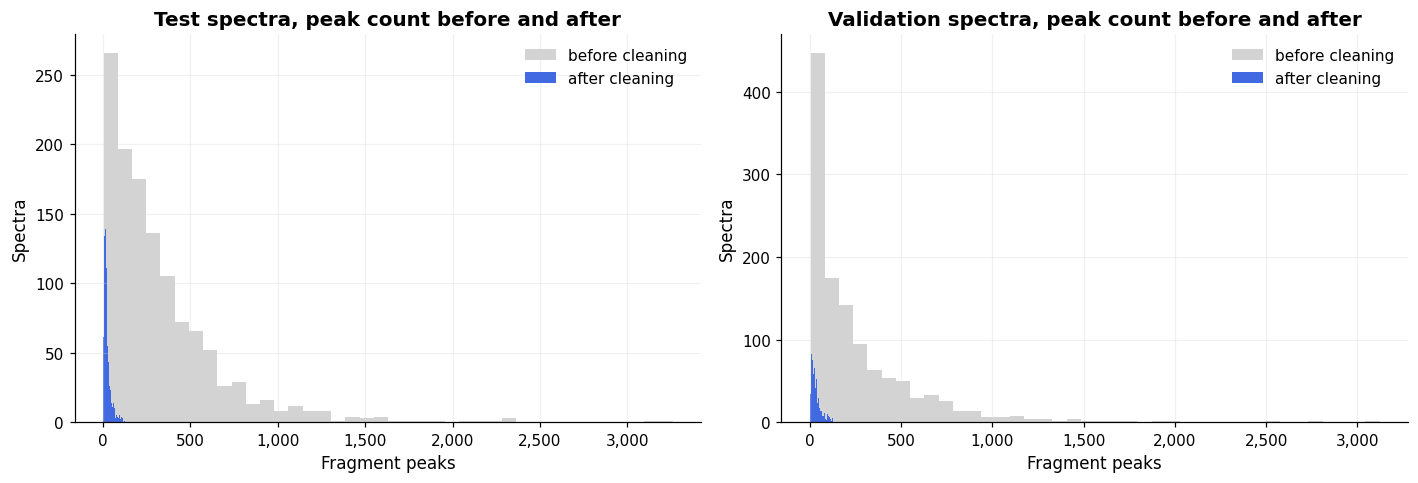

In [78]:
def clean_spectrum(mzs, intensities, precursor_mz, min_rel_intensity=0.01,
                   max_peaks=128, precursor_tol_da=2.0, window_da=None,
                   window_peaks=6, sqrt_transform=True):
    '''Reduce a raw peak list to its structurally informative core, identically on both sides.'''
    mzs = np.asarray(mzs, dtype=float)
    intensities = np.asarray(intensities, dtype=float)
    if mzs.size == 0:
        return mzs, intensities

    keep = mzs <= (precursor_mz + precursor_tol_da)
    mzs, intensities = mzs[keep], intensities[keep]
    if intensities.size == 0:
        return mzs, intensities

    base = intensities.max()
    if base > 0:
        keep = intensities >= (min_rel_intensity * base)
        mzs, intensities = mzs[keep], intensities[keep]
    if intensities.size == 0:
        return mzs, intensities

    if window_da:
        selected = []
        bins = np.floor(mzs / window_da).astype(int)
        for bin_id in np.unique(bins):
            in_bin = np.where(bins == bin_id)[0]
            ranked = in_bin[np.argsort(intensities[in_bin])[::-1][:window_peaks]]
            selected.extend(ranked.tolist())
        chosen = np.sort(np.asarray(selected, dtype=int))
    else:
        chosen = np.arange(mzs.size)

    mzs, intensities = mzs[chosen], intensities[chosen]
    if mzs.size > max_peaks:
        top = np.sort(np.argsort(intensities)[::-1][:max_peaks])
        mzs, intensities = mzs[top], intensities[top]

    base = intensities.max()
    if base > 0:
        intensities = intensities / base
    if sqrt_transform:
        intensities = np.sqrt(intensities)

    return mzs, intensities


def clean_frame(frame, **kwargs):
    '''Apply clean_spectrum across a dataframe of spectra, returning cleaned columns.'''
    cleaned = [
        clean_spectrum(row.ms2_mzs, row.ms2_normalized_intensities, row.precursor_mz, **kwargs)
        for row in frame.itertuples()
    ]
    frame = frame.copy()
    frame['clean_mzs'] = [pair[0] for pair in cleaned]
    frame['clean_intensities'] = [pair[1] for pair in cleaned]
    frame['clean_n_peaks'] = [pair[0].size for pair in cleaned]
    return frame


test_clean = clean_frame(test_df)
validation_clean = clean_frame(validation_df)

test_survivors = int((test_clean['clean_n_peaks'] >= 5).sum())
val_survivors = int((validation_clean['clean_n_peaks'] >= 5).sum())
distinct_answers = len(set(validation_answers.values()))

print('🧹 Spectral cleaning applied')
print(f'   Test: median {test_df["n_peaks"].median():,.0f} peaks before | {test_clean["clean_n_peaks"].median():,.0f} after')
print(f'   Validation: median {validation_df["num_peaks"].median():,.0f} peaks before | {validation_clean["clean_n_peaks"].median():,.0f} after')
print(f'   Test spectra retaining at least 5 peaks: {test_survivors:,} of {len(test_clean):,}')
print(f'   Validation spectra retaining at least 5 peaks: {val_survivors:,} of {len(validation_clean):,}')
if validation_answers:
    print(f'   Distinct canonical answers in validation: {distinct_answers:,} of {len(validation_answers):,}')
else:
    print('   ⏭️ Canonical answer keys unavailable without RDKit')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(test_df['n_peaks'], bins=40, color=LIGHT_GRAY, label='before cleaning')
ax.hist(test_clean['clean_n_peaks'], bins=40, color=ROYAL_BLUE, label='after cleaning')
ax.set_title('Test spectra, peak count before and after')
ax.set_xlabel('Fragment peaks')
ax.set_ylabel('Spectra')
ax.legend()
ax.xaxis.set_major_formatter(comma_fmt)
ax.yaxis.set_major_formatter(comma_fmt)

ax = axes[1]
ax.hist(validation_df['num_peaks'], bins=40, color=LIGHT_GRAY, label='before cleaning')
ax.hist(validation_clean['clean_n_peaks'], bins=40, color=ROYAL_BLUE, label='after cleaning')
ax.set_title('Validation spectra, peak count before and after')
ax.set_xlabel('Fragment peaks')
ax.set_ylabel('Spectra')
ax.legend()
ax.xaxis.set_major_formatter(comma_fmt)
ax.yaxis.set_major_formatter(comma_fmt)

plt.tight_layout()
plt.show()

#### **Choosing the cleaning parameters**

The two sides of every comparison come from different instruments and different curation practices, so the rule that preserves the most information is not necessarily the rule that makes the two comparable. The reference libraries show the spread directly: a median GNPS spectrum carries 46 peaks, RIKEN 9, and enveda-180 138. Cleaning has to land query and reference on the same footing before any similarity between them means anything.

The sweep varies the intensity floor and the peak ceiling and reports the median peak count on each side. Dropping the floor to 0.1% recovers every usable spectrum and all 400 test molecules, so the floor costs nothing. The ceiling is where the decision lives, and the column to read is the gap between the two medians rather than either median on its own.

In [79]:
cleaning_configs = {
    'floor 1.0%, top 128': dict(min_rel_intensity=0.010, max_peaks=128),
    'floor 0.5%, top 128': dict(min_rel_intensity=0.005, max_peaks=128),
    'floor 0.1%, top 128': dict(min_rel_intensity=0.001, max_peaks=128),
    'floor 0.1%, top 64': dict(min_rel_intensity=0.001, max_peaks=64),
    'floor 0.1%, top 32': dict(min_rel_intensity=0.001, max_peaks=32),
    'floor 0.1%, 6 per 50 Da': dict(min_rel_intensity=0.001, max_peaks=128,
                                    window_da=50.0, window_peaks=6),
}

sweep_rows = []
for label, params in cleaning_configs.items():
    swept_test = clean_frame(test_df, **params)
    swept_val = clean_frame(validation_df, **params)
    usable_test = swept_test[swept_test['clean_n_peaks'] >= 5]
    usable_val = swept_val[swept_val['clean_n_peaks'] >= 5]
    sweep_rows.append({
        'config': label,
        'test_median': swept_test['clean_n_peaks'].median(),
        'val_median': swept_val['clean_n_peaks'].median(),
        'gap': abs(swept_test['clean_n_peaks'].median() - swept_val['clean_n_peaks'].median()),
        'test_usable': len(usable_test),
        'val_usable': len(usable_val),
        'molecules_covered': usable_test['molecule_id'].nunique(),
    })

sweep = pd.DataFrame(sweep_rows).set_index('config')

print('🔧 Cleaning parameter sweep')
print(f'   Reference library medians before cleaning: gnps 46 | riken 9 | enveda-180 138')
print(f'   Test molecules needing coverage: {n_molecules:,}')
print()
print(sweep)

🔧 Cleaning parameter sweep
   Reference library medians before cleaning: gnps 46 | riken 9 | enveda-180 138
   Test molecules needing coverage: 400

                         test_median  val_median     gap  test_usable  val_usable  molecules_covered
config                                                                                              
floor 1.0%, top 128          18.0000     28.0000 10.0000         1181        1150                398
floor 0.5%, top 128          25.0000     39.0000 14.0000         1199        1172                400
floor 0.1%, top 128          52.0000     73.0000 21.0000         1208        1179                400
floor 0.1%, top 64           52.0000     64.0000 12.0000         1208        1179                400
floor 0.1%, top 32           32.0000     32.0000  0.0000         1208        1179                400
floor 0.1%, 6 per 50 Da      23.0000     28.0000  5.0000         1208        1179                400


### **Section 5: Recovering neutral mass from the measured precursor**

A mass spectrometer measures the mass of an ion, not of the molecule. The adduct describes what was gained or lost during ionization, and reversing it is what turns a measured precursor into the neutral monoisotopic mass that can be compared against a candidate structure. An error of one hydrogen here is roughly 4,000 ppm at these masses, which would silently empty every candidate list while the pipeline appeared to run correctly.

1. Tabulate the offset from measured precursor to neutral mass for each of the ten adducts the test set can contain.
2. Recover neutral mass for every validation spectrum, where the true structure is known.
3. Compare each recovered mass against the exact mass computed from that structure, and report the error per adduct.
4. Confirm that every adduct present in the test set is covered by the table.

In [80]:
ADDUCT_NEUTRAL_OFFSET = {
    '[M+H]+': -1.00727645,
    '[M+NH4]+': -18.03382550,
    '[M-H2O+H]+': 17.00328815,
    '[M-2H2O+H]+': 35.01385275,
    '[M+Na]+': -22.98922070,
    '[M+K]+': -38.96315790,
    '[M-H]-': 1.00727645,
    '[M-H2O-H]-': 19.01784105,
    '[M+CH2O2-H]-': -44.99820285,
    '[M+Cl]-': -34.96940126,
}

_exact_mass_cache = {}


def neutral_mass(precursor_mz, adduct):
    '''Reverse the ionization adduct to recover the neutral monoisotopic mass.'''
    offset = ADDUCT_NEUTRAL_OFFSET.get(adduct)
    return np.nan if offset is None else precursor_mz + offset


def exact_mass_from_smiles(smiles):
    '''Monoisotopic mass of a structure, computed from its SMILES and cached.'''
    if not RDKIT_AVAILABLE:
        return np.nan
    if smiles not in _exact_mass_cache:
        mol = Chem.MolFromSmiles(smiles)
        _exact_mass_cache[smiles] = np.nan if mol is None else Descriptors.ExactMolWt(mol)
    return _exact_mass_cache[smiles]

if RDKIT_AVAILABLE:
    check = validation_df[['adduct', 'precursor_mz', 'normalized_smiles']].copy()
    check['recovered'] = [
        neutral_mass(row.precursor_mz, row.adduct) for row in check.itertuples()
    ]
    check['truth'] = [exact_mass_from_smiles(smiles) for smiles in check['normalized_smiles']]
    check['ppm_error'] = (check['recovered'] - check['truth']) / check['truth'] * 1_000_000
    adduct_accuracy = check.groupby('adduct').agg(
        spectra=('ppm_error', 'size'),
        median_abs_ppm=('ppm_error', lambda s: s.abs().median()),
        max_abs_ppm=('ppm_error', lambda s: s.abs().max()),
    ).sort_values('spectra', ascending=False)
    
    uncovered = sorted(set(test_df['adduct']) - set(ADDUCT_NEUTRAL_OFFSET))
    within_tolerance = int((check['ppm_error'].abs() <= PPM_TOLERANCE).sum())
    
    print('⚖️ Neutral mass recovery')
    print(f'   Validation spectra checked: {len(check):,}')
    print(f'   Within {PPM_TOLERANCE:,.0f} ppm of the true mass: {within_tolerance:,} ({within_tolerance / len(check):.1%})')
    print(f'   Test adducts missing from the offset table: {uncovered if uncovered else "none"}')
    print()
    print(adduct_accuracy)
    
else:
    print('⏭️ Adduct verification skipped, RDKit unavailable')

⚖️ Neutral mass recovery
   Validation spectra checked: 1,184
   Within 15 ppm of the true mass: 1,183 (99.9%)
   Test adducts missing from the offset table: none

              spectra  median_abs_ppm  max_abs_ppm
adduct                                            
[M+H]+            569          2.0248       8.7693
[M-H]-            276          0.9407      21.0095
[M+CH2O2-H]-      105          0.8534       8.4443
[M+NH4]+           98          1.3903       4.0959
[M+Na]+            80          1.8218       7.2430
[M-H2O+H]+         24          2.1012       6.9692
[M+K]+             16          1.8515      12.6473
[M-2H2O+H]+         8          1.5799       3.3094
[M+Cl]-             7          0.4771       2.6099
[M-H2O-H]-          1          4.4487       4.4487


### **Section 6: Precomputing canonical structure keys**

Section 3 established that 6.4% of structures receive a different key after tautomer canonicalization than the `inchikey14` column shipped with the training data, and that the scorer canonicalizes while the shipped column does not. Every structural comparison in this pipeline therefore has to use the canonical key. Canonicalization is far too slow to run at query time, so it is computed once for every structure in the reference index and cached to disk.

The reference index is restricted to the natural product libraries. Section 2 showed that enveda-180 contributes 182,941 of the 275,810 distinct structures while being drawn from synthetic drug-like chemical space, so including it triples the search space with molecules the test set is unlikely to contain. That restriction is a hypothesis, and it is tested against the alternative later rather than assumed.

1. Select the libraries that form the reference index and load only their structure columns.
2. Reduce to distinct structures, since a compound measured a hundred times needs canonicalizing once.
3. Compute the canonical key for each, reporting progress, and cache the result to the working directory.
4. Report how many keys shifted and how many structures failed to parse.

In [81]:
INDEX_LIBS = NATURAL_PRODUCT_LIBS + ['masaryk', 'drug_plus']
CANONICAL_CACHE = cache_path('canonical_keys.parquet')

structure_rows = load_train(
    columns=['ingest_lib', 'inchikey14', 'normalized_smiles'],
    libraries=INDEX_LIBS,
)
structures = (
    structure_rows
    .drop_duplicates('normalized_smiles')[['inchikey14', 'normalized_smiles']]
    .reset_index(drop=True)
)

print(f'🗂️ Index libraries: {", ".join(INDEX_LIBS)}')
print(f'   Spectra available: {len(structure_rows):,}')
print(f'   Distinct structures to canonicalize: {len(structures):,}')

if CANONICAL_CACHE.exists():
    canonical_df = pd.read_parquet(CANONICAL_CACHE)
    mirror_to_working(CANONICAL_CACHE)
    print(f'💾 Loaded cached canonical keys: {len(canonical_df):,}')
else:
    started = time.time()
    resolved = []
    total = len(structures)
    for position, smiles in enumerate(structures['normalized_smiles'], start=1):
        resolved.append(smiles_to_inchikey14(smiles))
        if position % 5_000 == 0 or position == total:
            elapsed = time.time() - started
            remaining = (total - position) * elapsed / position
            print(f'   ⏳ {position:,} of {total:,} | {elapsed / 60:,.1f} min elapsed | {remaining / 60:,.1f} min left')
    canonical_df = structures.copy()
    canonical_df['canonical_key14'] = resolved
    canonical_df.to_parquet(CANONICAL_CACHE, index=False)
    print(f'💾 Cached to {CANONICAL_CACHE.name}')

parse_failures = int(canonical_df['canonical_key14'].isna().sum())
shifted = int((canonical_df['canonical_key14'] != canonical_df['inchikey14']).sum())
usable = canonical_df.dropna(subset=['canonical_key14'])

print()
print('🔑 Canonical key summary')
print(f'   Structures: {len(canonical_df):,} | parse failures: {parse_failures:,}')
print(f'   Keys shifted under canonicalization: {shifted:,} ({shifted / len(canonical_df):.1%})')
print(f'   Distinct canonical structures in the index: {usable["canonical_key14"].nunique():,}')

🗂️ Index libraries: gnps, riken, massbank, mona, spectraverse, msdial, masaryk, drug_plus
   Spectra available: 857,058
   Distinct structures to canonicalize: 66,490
💾 Loaded cached canonical keys: 66,490

🔑 Canonical key summary
   Structures: 66,490 | parse failures: 0
   Keys shifted under canonicalization: 2,904 (4.4%)
   Distinct canonical structures in the index: 63,449


### **Section 7: Auditing reference mass quality**

A reference index is only as trustworthy as the masses it is keyed on. An initial build indexed each reference spectrum by the neutral mass recovered from its measured precursor, and returned a mass range topping out at 2,430,334 Da, roughly a thousand times heavier than any small molecule. One implausible value is reason enough to audit the whole reference set before building anything on top of it.

The training data ships `precursor_error_ppm`, the disagreement between each spectrum's measured precursor and the value implied by its labeled structure and adduct, deliberately uncleaned so that it can serve as a label quality signal. Section 2 reported per-library medians of this quantity between 0.65 and 3.75 ppm and took that as evidence the libraries were clean. That reading was an artifact of the statistic: a median is robust by construction, which is exactly what makes it blind to a contaminated minority.

1. Recover neutral mass for every reference spectrum and pair it with the shipped label disagreement.
2. Report the full percentile structure of that disagreement rather than its centre.
3. Count rows exceeding a range of candidate thresholds.
4. Test whether a simple mass range filter would have been sufficient on its own.

In [82]:
quality = load_train(
    columns=['ingest_lib', 'normalized_smiles', 'adduct', 'precursor_mz', 'precursor_error_ppm'],
    libraries=INDEX_LIBS,
)
quality['neutral_mass'] = quality['precursor_mz'] + quality['adduct'].map(ADDUCT_NEUTRAL_OFFSET)
quality['abs_ppm'] = quality['precursor_error_ppm'].abs()

percentiles = quality['abs_ppm'].quantile([0.5, 0.9, 0.99, 0.999, 0.9999, 1.0])
thresholds = [10, 20, 50, 100, 1_000]
implausible = quality[(quality['neutral_mass'] < 50) | (quality['neutral_mass'] > 2_000)]

print('🔍 Reference mass quality')
print(f'   Spectra examined: {len(quality):,}')
print(f'   Missing precursor_error_ppm: {quality["precursor_error_ppm"].isna().sum():,}')
print()
print('   Absolute ppm error percentiles')
for level, value in percentiles.items():
    print(f'      {level:.4%}: {value:,.2f} ppm')
print()
for cut in thresholds:
    over = int((quality['abs_ppm'] > cut).sum())
    print(f'   Above {cut:,} ppm: {over:,} ({over / len(quality):.3%})')
print()
print(f'   Neutral mass outside 50 to 2,000 Da: {len(implausible):,}')
print(implausible.groupby('ingest_lib').size().sort_values(ascending=False))
print()
print('   Ten worst masses')
print(
    quality.nlargest(10, 'neutral_mass')[['ingest_lib', 'adduct', 'precursor_mz', 'neutral_mass', 'abs_ppm']]
    .to_string(index=False)
)

🔍 Reference mass quality
   Spectra examined: 857,058
   Missing precursor_error_ppm: 4,071

   Absolute ppm error percentiles
      50.0000%: 2.01 ppm
      90.0000%: 15.03 ppm
      99.0000%: 87,468.07 ppm
      99.9000%: 582,673.28 ppm
      99.9900%: 1,899,355.27 ppm
      100.0000%: 469,771,545.80 ppm

   Above 10 ppm: 124,276 (14.500%)
   Above 20 ppm: 68,723 (8.018%)
   Above 50 ppm: 50,447 (5.886%)
   Above 100 ppm: 47,491 (5.541%)
   Above 1,000 ppm: 26,267 (3.065%)

   Neutral mass outside 50 to 2,000 Da: 65
ingest_lib
gnps         25
riken        13
msdial       11
massbank     10
mona          5
drug_plus     1
dtype: int64

   Ten worst masses
ingest_lib  adduct   precursor_mz   neutral_mass      abs_ppm
      mona  [M-H]- 2,430,333.0000 2,430,334.0073 999,900.0002
      gnps  [M+H]+     3,355.6000     3,354.5927   3,268.7686
    msdial  [M+H]+     2,679.4869     2,678.4796       0.2048
     riken  [M+H]+     2,679.4800     2,678.4727       2.7760
     riken  [M+H]+     2,

### **Section 8: Building the reference index**

The audit established that 5.5% of reference spectra disagree with their own labeled structure by more than 100 ppm, while only 65 of 857,058 carry an implausible mass outright. The contamination is therefore almost entirely masses that look reasonable and are wrong, which is the kind that survives a range filter and lands inside query windows as confident false candidates.

Every training row carries a labeled structure whose exact mass is computable, so the index is keyed on the structure-derived mass rather than the measured precursor. This removes the contamination entirely and, as a secondary benefit, removes the reference side's measurement error from every comparison, leaving only the query's. The measured precursor remains the only option on the query side, where no label exists.

A large label disagreement is separately retained as a quality signal, since a row whose mass is wrong by three orders of magnitude gives little reason to trust its peak list either.

1. Compute the exact monoisotopic mass of every distinct structure once and cache it.
2. Key each reference spectrum to its structure's exact mass.
3. Discard rows whose label disagreement exceeds the threshold, retaining those where the signal is missing.
4. Clean with the same function and parameters used on the query side, flatten, sort by mass, and cache.

In [83]:
MAX_LABEL_PPM = 50.0
MIN_INDEX_PEAKS = 5
CLEAN_PARAMS = dict(min_rel_intensity=0.001, max_peaks=32)

_top_n = CLEAN_PARAMS['max_peaks']
INDEX_TAG = f'p{int(MAX_LABEL_PPM)}_m{MIN_INDEX_PEAKS}_t{_top_n}'
EXACT_MASS_CACHE = cache_path('structure_exact_mass.parquet')
INDEX_CACHE = cache_path(f'reference_index_{INDEX_TAG}.npz')
INDEX_META_CACHE = cache_path(f'reference_index_meta_{INDEX_TAG}.parquet')

canonical_lookup = dict(zip(canonical_df['normalized_smiles'], canonical_df['canonical_key14']))

if EXACT_MASS_CACHE.exists():
    mass_df = pd.read_parquet(EXACT_MASS_CACHE)
    mirror_to_working(EXACT_MASS_CACHE)
    print(f'💾 Loaded cached exact masses: {len(mass_df):,}')
else:
    started = time.time()
    mass_df = canonical_df[['normalized_smiles', 'canonical_key14']].copy()
    mass_df['exact_mass'] = [
        exact_mass_from_smiles(smiles) for smiles in mass_df['normalized_smiles']
    ]
    mass_df.to_parquet(EXACT_MASS_CACHE, index=False)
    print(f'💾 Exact masses computed in {(time.time() - started) / 60:,.1f} min')

exact_mass_lookup = dict(zip(mass_df['normalized_smiles'], mass_df['exact_mass']))


def build_library_chunk(library):
    '''Clean one source library into flat peak arrays keyed by structure-derived mass.'''
    frame = load_train(
        columns=[
            'normalized_smiles', 'adduct', 'ionization_mode', 'precursor_mz',
            'precursor_error_ppm', 'ms2_mzs', 'ms2_normalized_intensities',
            'collision_energy_ev',
        ],
        libraries=[library],
    )
    frame['neutral_mass'] = frame['normalized_smiles'].map(exact_mass_lookup)
    label_ppm = frame['precursor_error_ppm'].abs()
    frame = frame[
        frame['neutral_mass'].notna()
        & (label_ppm.isna() | (label_ppm <= MAX_LABEL_PPM))
    ]

    mz_parts, intensity_parts, kept_rows, peak_counts = [], [], [], []
    for row in frame.itertuples():
        mzs, intensities = clean_spectrum(
            row.ms2_mzs, row.ms2_normalized_intensities, row.precursor_mz, **CLEAN_PARAMS
        )
        if mzs.size >= MIN_INDEX_PEAKS:
            mz_parts.append(mzs)
            intensity_parts.append(intensities)
            kept_rows.append(row.Index)
            peak_counts.append(mzs.size)

    meta = frame.loc[
        kept_rows, ['normalized_smiles', 'adduct', 'ionization_mode', 'neutral_mass']
    ].copy()
    meta['library'] = library
    meta['n_peaks'] = peak_counts
    meta['collision_energy'] = [
        float(np.mean(energy)) if energy is not None and len(energy) else np.nan
        for energy in frame.loc[kept_rows, 'collision_energy_ev']
    ]
    return meta, mz_parts, intensity_parts


if INDEX_CACHE.exists() and INDEX_META_CACHE.exists():
    stored = np.load(INDEX_CACHE)
    index_mzs = stored['mzs']
    index_intensities = stored['intensities']
    index_offsets = stored['offsets']
    index_meta = pd.read_parquet(INDEX_META_CACHE)
    mirror_to_working(INDEX_CACHE)
    mirror_to_working(INDEX_META_CACHE)
    print(f'💾 Loaded cached index: {len(index_meta):,} spectra')
else:
    started = time.time()
    meta_parts, all_mzs, all_intensities = [], [], []
    for library in INDEX_LIBS:
        meta, mz_parts, intensity_parts = build_library_chunk(library)
        meta_parts.append(meta)
        all_mzs.extend(mz_parts)
        all_intensities.extend(intensity_parts)
        print(f'   ⏳ {library}: {len(meta):,} spectra kept | {(time.time() - started) / 60:,.1f} min elapsed')

    index_meta = pd.concat(meta_parts, ignore_index=True)
    index_meta['canonical_key14'] = index_meta['normalized_smiles'].map(canonical_lookup)
    index_meta = index_meta[index_meta['canonical_key14'].notna()]

    order = np.argsort(index_meta['neutral_mass'].to_numpy(), kind='stable')
    index_meta = index_meta.iloc[order].reset_index(drop=True)
    all_mzs = [all_mzs[position] for position in order]
    all_intensities = [all_intensities[position] for position in order]

    index_offsets = np.zeros(len(all_mzs) + 1, dtype=np.int64)
    index_offsets[1:] = np.cumsum([array.size for array in all_mzs])
    index_mzs = np.concatenate(all_mzs)
    index_intensities = np.concatenate(all_intensities)

    np.savez_compressed(INDEX_CACHE, mzs=index_mzs, intensities=index_intensities, offsets=index_offsets)
    index_meta.to_parquet(INDEX_META_CACHE, index=False)
    print(f'💾 Cached index in {(time.time() - started) / 60:,.1f} min')

index_masses = index_meta['neutral_mass'].to_numpy()

print()
print('📇 Reference index')
print(f'   Spectra: {len(index_meta):,} | distinct molecules: {index_meta["canonical_key14"].nunique():,}')
print(f'   Neutral mass range: {index_masses.min():,.1f} to {index_masses.max():,.1f} Da')
print(f'   Peaks stored: {index_mzs.size:,} | median per spectrum: {index_meta["n_peaks"].median():,.0f}')
print(f'   Memory held by peak arrays: {index_mzs.size * 16 / (1024 ** 2):,.0f} MB')

💾 Loaded cached exact masses: 66,490
💾 Loaded cached index: 644,652 spectra

📇 Reference index
   Spectra: 644,652 | distinct molecules: 61,022
   Neutral mass range: 44.0 to 3,399.6 Da
   Peaks stored: 14,419,295 | median per spectrum: 27
   Memory held by peak arrays: 220 MB


### **Section 9: Scoring spectral similarity**

Two spectra are compared by matching their fragment peaks within a mass tolerance and scoring the agreement of the matched intensities. The choice of score matters more here than it usually would, because Section 2 established that reference spectra arrive at wildly different peak densities and no amount of cleaning can raise a nine-peak RIKEN spectrum to meet a thirty-peak query.

Two scores are therefore computed for every comparison. A cosine similarity normalizes by the magnitude of both spectra, which is the right behaviour when both were recorded comparably, and penalizes a sparse reference for peaks it never had the opportunity to record. A reference coverage score asks only what fraction of the reference's intensity the query accounts for, and is indifferent to the query carrying more peaks than the reference. Neither is correct in general; they fail in opposite directions, which is the argument for carrying both.

1. Confirm that stored peak lists are sorted by mass, which the matching routine assumes.
2. Match peaks one to one within a mass tolerance, resolving contested assignments in favour of the closest.
3. Compute the symmetric cosine and the asymmetric reference coverage.
4. Verify both against cases whose answers are known by construction.
5. Benchmark throughput, since the full run involves on the order of a million comparisons.

In [84]:
FRAGMENT_TOL_PPM = 20.0
FRAGMENT_TOL_FLOOR_DA = 0.005


def spectrum_at(position):
    '''Return the stored peak arrays for one index row.'''
    start, stop = index_offsets[position], index_offsets[position + 1]
    return index_mzs[start:stop], index_intensities[start:stop]


def match_peaks(query_mzs, ref_mzs):
    '''One-to-one nearest peak matches within tolerance, closest assignment winning.'''
    if query_mzs.size == 0 or ref_mzs.size == 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)

    tolerance = np.maximum(FRAGMENT_TOL_FLOOR_DA, query_mzs * FRAGMENT_TOL_PPM / 1_000_000)
    slots = np.searchsorted(ref_mzs, query_mzs)
    left = np.clip(slots - 1, 0, ref_mzs.size - 1)
    right = np.clip(slots, 0, ref_mzs.size - 1)
    left_gap = np.abs(ref_mzs[left] - query_mzs)
    right_gap = np.abs(ref_mzs[right] - query_mzs)
    nearest = np.where(left_gap <= right_gap, left, right)
    gap = np.minimum(left_gap, right_gap)

    within = gap <= tolerance
    query_idx = np.nonzero(within)[0]
    ref_idx = nearest[within]
    if ref_idx.size > 1:
        order = np.lexsort((gap[within], ref_idx))
        query_idx, ref_idx = query_idx[order], ref_idx[order]
        keep = np.ones(ref_idx.size, dtype=bool)
        keep[1:] = ref_idx[1:] != ref_idx[:-1]
        query_idx, ref_idx = query_idx[keep], ref_idx[keep]
    return query_idx, ref_idx


def similarity_scores(query_mzs, query_intensities, ref_mzs, ref_intensities):
    '''Symmetric cosine and asymmetric reference coverage for one spectrum pair.'''
    query_idx, ref_idx = match_peaks(query_mzs, ref_mzs)
    if query_idx.size == 0:
        return 0.0, 0.0
    dot = float(np.dot(query_intensities[query_idx], ref_intensities[ref_idx]))
    norms = float(np.linalg.norm(query_intensities) * np.linalg.norm(ref_intensities))
    cosine = dot / norms if norms > 0 else 0.0
    ref_total = float(ref_intensities.sum())
    coverage = float(ref_intensities[ref_idx].sum()) / ref_total if ref_total > 0 else 0.0
    return cosine, coverage


sorted_sample = [
    bool(np.all(np.diff(spectrum_at(position)[0]) >= 0))
    for position in np.random.default_rng(RANDOM_STATE).integers(0, len(index_meta), 2_000)
]

probe_mzs, probe_intensities = spectrum_at(0)
shifted_mzs = probe_mzs + 5.0

checks = {
    'spectrum against itself': similarity_scores(probe_mzs, probe_intensities, probe_mzs, probe_intensities),
    'spectrum against a 5 Da shift of itself': similarity_scores(probe_mzs, probe_intensities, shifted_mzs, probe_intensities),
}

rng = np.random.default_rng(RANDOM_STATE)
benchmark_rows = rng.integers(0, len(index_meta), 5_000)
started = time.time()
for position in benchmark_rows:
    ref_mzs, ref_intensities = spectrum_at(position)
    similarity_scores(probe_mzs, probe_intensities, ref_mzs, ref_intensities)
per_comparison = (time.time() - started) / len(benchmark_rows)

print('🔗 Similarity scoring')
print(f'   Peak lists sorted by mass: {all(sorted_sample)} (sampled {len(sorted_sample):,})')
for label, (cosine, coverage) in checks.items():
    print(f'   {label}: cosine {cosine:,.4f} | coverage {coverage:,.4f}')
print()
print(f'   Throughput: {per_comparison * 1_000_000:,.0f} microseconds per comparison')
print(f'   Projected cost of 1,000,000 comparisons: {per_comparison * 1_000_000 / 60:,.1f} min')

probe_rng = np.random.default_rng(RANDOM_STATE)
keys = index_meta['canonical_key14'].to_numpy()
libraries = index_meta['library'].to_numpy()

key_positions = index_meta.groupby('canonical_key14').indices
repeated = [positions for positions in key_positions.values() if positions.size >= 2]
chosen = probe_rng.choice(len(repeated), size=min(500, len(repeated)), replace=False)

same_scores, cross_library = [], 0
for slot in chosen:
    positions = repeated[slot]
    distinct_libs = np.unique(libraries[positions])
    if distinct_libs.size >= 2:
        first = probe_rng.choice(np.nonzero(libraries[positions] == distinct_libs[0])[0])
        second = probe_rng.choice(np.nonzero(libraries[positions] == distinct_libs[1])[0])
        left, right = positions[first], positions[second]
        cross_library += 1
    else:
        left, right = probe_rng.choice(positions, size=2, replace=False)
    same_scores.append(similarity_scores(*spectrum_at(left), *spectrum_at(right)))

neighbour_gap_ppm = np.abs(np.diff(index_masses)) / index_masses[:-1] * 1_000_000
confusable = np.nonzero((keys[:-1] != keys[1:]) & (neighbour_gap_ppm <= PPM_TOLERANCE))[0]
decoy_sample = probe_rng.choice(confusable, size=min(500, confusable.size), replace=False)
decoy_scores = [similarity_scores(*spectrum_at(pos), *spectrum_at(pos + 1)) for pos in decoy_sample]

same_cosine = np.array([pair[0] for pair in same_scores])
same_coverage = np.array([pair[1] for pair in same_scores])
decoy_cosine = np.array([pair[0] for pair in decoy_scores])
decoy_coverage = np.array([pair[1] for pair in decoy_scores])

print('🎯 Separation check')
print(f'   Same molecule, independent spectra: {len(same_scores):,} pairs ({cross_library:,} across libraries)')
print(f'      cosine   median {np.median(same_cosine):,.4f} | quartiles {np.percentile(same_cosine, 25):,.4f} to {np.percentile(same_cosine, 75):,.4f}')
print(f'      coverage median {np.median(same_coverage):,.4f} | quartiles {np.percentile(same_coverage, 25):,.4f} to {np.percentile(same_coverage, 75):,.4f}')
print(f'   Different molecules within {PPM_TOLERANCE:,.0f} ppm: {len(decoy_scores):,} pairs')
print(f'      cosine   median {np.median(decoy_cosine):,.4f} | 95th {np.percentile(decoy_cosine, 95):,.4f}')
print(f'      coverage median {np.median(decoy_coverage):,.4f} | 95th {np.percentile(decoy_coverage, 95):,.4f}')

🔗 Similarity scoring
   Peak lists sorted by mass: True (sampled 2,000)
   spectrum against itself: cosine 1.0000 | coverage 1.0000
   spectrum against a 5 Da shift of itself: cosine 0.0000 | coverage 0.0000

   Throughput: 29 microseconds per comparison
   Projected cost of 1,000,000 comparisons: 0.5 min
🎯 Separation check
   Same molecule, independent spectra: 500 pairs (170 across libraries)
      cosine   median 0.6408 | quartiles 0.0459 to 0.9325
      coverage median 0.6028 | quartiles 0.0759 to 0.8928
   Different molecules within 15 ppm: 500 pairs
      cosine   median 0.0096 | 95th 0.5683
      coverage median 0.0236 | 95th 0.5560


### **Section 10: What drives the failures**

A quarter of same-molecule pairs score below 0.046, which is under the median for unrelated molecules. An interquartile range spanning 0.046 to 0.93 within what should be a single population indicates a hidden variable rather than noise. Two candidates are testable directly: collision energy, since the same molecule fragmented at 10 eV and at 60 eV produces genuinely different spectra, and source library, since Section 2 established that each library curated its spectra to a different density.

1. Sample same-library and cross-library pairs separately so the two variables are not confounded.
2. Record collision energy difference and peak count ratio alongside each score.
3. Report median similarity by energy gap and by library relationship.

🔬 Failure decomposition
   Pairs scored: 5,130 | energy known for 894

               pairs  median_cosine  median_coverage  median_peak_ratio
relation                                                               
cross library   1451         0.5580           0.5187             1.2308
same library    3679         0.5572           0.5234             1.1000

            pairs  median_cosine  median_coverage
energy_bin                                       
identical     307         0.8907           0.7594
up to 5 eV     76         0.0089           0.0250
5 to 10       133         0.7305           0.6512
10 to 20      172         0.4565           0.4576
20 to 40      142         0.2151           0.2831
over 40        64         0.0000           0.0000

   Spearman correlation, energy gap against cosine: -0.3636
   Spearman correlation, peak ratio against cosine: -0.2975


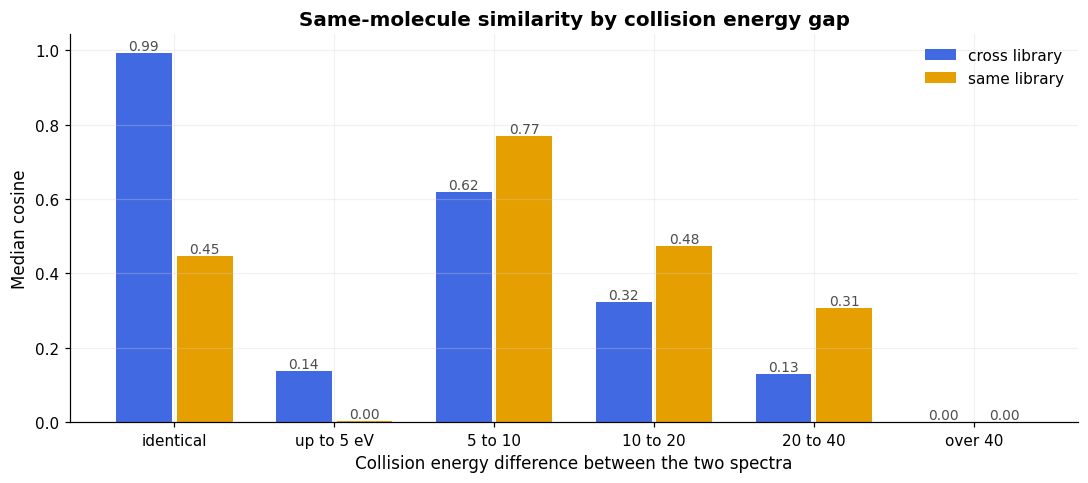

In [85]:
split_rng = np.random.default_rng(RANDOM_STATE + 1)
energies = index_meta['collision_energy'].to_numpy()
peak_counts = index_meta['n_peaks'].to_numpy()

repeated_keys = [positions for positions in key_positions.values() if positions.size >= 2]
sampled_groups = split_rng.choice(len(repeated_keys), size=min(4_000, len(repeated_keys)), replace=False)

pairs = []
for slot in sampled_groups:
    positions = repeated_keys[slot]
    libs = libraries[positions]
    unique_libs = np.unique(libs)
    for lib in unique_libs:
        in_lib = positions[libs == lib]
        if in_lib.size >= 2:
            left, right = split_rng.choice(in_lib, size=2, replace=False)
            pairs.append((left, right, 'same library'))
            break
    if unique_libs.size >= 2:
        first, second = split_rng.choice(unique_libs, size=2, replace=False)
        left = split_rng.choice(positions[libs == first])
        right = split_rng.choice(positions[libs == second])
        pairs.append((left, right, 'cross library'))

records = []
for left, right, relation in pairs:
    cosine, coverage = similarity_scores(*spectrum_at(left), *spectrum_at(right))
    records.append({
        'relation': relation,
        'cosine': cosine,
        'coverage': coverage,
        'energy_gap': abs(energies[left] - energies[right]),
        'peak_ratio': max(peak_counts[left], peak_counts[right]) / min(peak_counts[left], peak_counts[right]),
    })

split = pd.DataFrame(records)
split['energy_bin'] = pd.cut(
    split['energy_gap'],
    bins=[-0.001, 0.001, 5, 10, 20, 40, np.inf],
    labels=['identical', 'up to 5 eV', '5 to 10', '10 to 20', '20 to 40', 'over 40'],
)

by_relation = split.groupby('relation').agg(
    pairs=('cosine', 'size'),
    median_cosine=('cosine', 'median'),
    median_coverage=('coverage', 'median'),
    median_peak_ratio=('peak_ratio', 'median'),
)
by_energy = split.groupby('energy_bin', observed=True).agg(
    pairs=('cosine', 'size'),
    median_cosine=('cosine', 'median'),
    median_coverage=('coverage', 'median'),
)
known_energy = split.dropna(subset=['energy_gap'])

print('🔬 Failure decomposition')
print(f'   Pairs scored: {len(split):,} | energy known for {len(known_energy):,}')
print()
print(by_relation)
print()
print(by_energy)
print()
print(f'   Spearman correlation, energy gap against cosine: {known_energy["energy_gap"].corr(known_energy["cosine"], method="spearman"):,.4f}')
print(f'   Spearman correlation, peak ratio against cosine: {split["peak_ratio"].corr(split["cosine"], method="spearman"):,.4f}')

pivot = split.pivot_table(index='energy_bin', columns='relation', values='cosine',
                          aggfunc='median', observed=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(pivot))
width = 0.38
for offset, (relation, color) in enumerate(zip(pivot.columns, [ROYAL_BLUE, AMBER])):
    bars = ax.bar(positions + (offset - 0.5) * width, pivot[relation], width * 0.92,
                  color=color, label=relation)
    for bar, value in zip(bars, pivot[relation]):
        if not np.isnan(value):
            ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.2f}',
                    ha='center', va='bottom', fontsize=9, color=DARK_GRAY)
ax.set_xticks(positions)
ax.set_xticklabels(pivot.index)
ax.set_title('Same-molecule similarity by collision energy gap')
ax.set_xlabel('Collision energy difference between the two spectra')
ax.set_ylabel('Median cosine')
ax.legend()

plt.tight_layout()
plt.show()

#### **Adduct, the variable underneath the others**

Collision energy and source library were the two hypotheses worth testing first, and neither accounts for the spread alone. A third variable does, and unlike the others it is declared by the query rather than inferred: the adduct.

A molecule ionizes in several ways, and what gets fragmented is not the molecule but the molecule plus whatever it picked up. A sodiated ion and a protonated ion of the same compound fragment along different pathways and share few peaks. Splitting the same pairs by adduct separates the population cleanly, and splitting by ionization mode separates it absolutely. The energy effect survives inside the matched group, which is what makes it a real effect rather than an artifact of adduct mismatch. Pair counts are reported alongside every median so that no cell is read as evidence on the strength of a handful of comparisons.

In [86]:
adducts = index_meta['adduct'].to_numpy()
modes = index_meta['ionization_mode'].to_numpy()
relation_counts = split.pivot_table(
    index='energy_bin', columns='relation', values='cosine', aggfunc='size', observed=True,
)

records = []
for left, right, relation in pairs:
    cosine, coverage = similarity_scores(*spectrum_at(left), *spectrum_at(right))
    records.append({
        'relation': relation,
        'cosine': cosine,
        'coverage': coverage,
        'energy_gap': abs(energies[left] - energies[right]),
        'peak_ratio': max(peak_counts[left], peak_counts[right]) / min(peak_counts[left], peak_counts[right]),
        'adduct_match': 'same adduct' if adducts[left] == adducts[right] else 'different adduct',
        'mode_match': 'same mode' if modes[left] == modes[right] else 'different mode',
    })

split = pd.DataFrame(records)
split['energy_bin'] = pd.cut(
    split['energy_gap'],
    bins=[-0.001, 0.001, 5, 10, 20, 40, np.inf],
    labels=['identical', 'up to 5 eV', '5 to 10', '10 to 20', '20 to 40', 'over 40'],
)

by_adduct = split.groupby('adduct_match').agg(
    pairs=('cosine', 'size'), median_cosine=('cosine', 'median'), median_coverage=('coverage', 'median'),
)
by_mode = split.groupby('mode_match').agg(
    pairs=('cosine', 'size'), median_cosine=('cosine', 'median'),
)
adduct_by_energy = split.pivot_table(
    index='energy_bin', columns='adduct_match', values='cosine', aggfunc='median', observed=True,
)
adduct_counts = split.pivot_table(
    index='energy_bin', columns='adduct_match', values='cosine', aggfunc='size', observed=True,
)

print('🧪 Adduct decomposition')
print(by_adduct)
print()
print(by_mode)
print()
print('   Median cosine by energy gap and adduct match')
print(adduct_by_energy)
print()
print('   Pair counts behind those medians')
print(adduct_counts)
print()
print('   Pair counts by energy gap and library relation')
print(relation_counts)

🧪 Adduct decomposition
                  pairs  median_cosine  median_coverage
adduct_match                                           
different adduct   1781         0.0188           0.0430
same adduct        3349         0.8160           0.7509

                pairs  median_cosine
mode_match                          
different mode    709         0.0000
same mode        4421         0.6925

   Median cosine by energy gap and adduct match
adduct_match  different adduct  same adduct
energy_bin                                 
identical               0.0000       0.9573
up to 5 eV              0.0000       0.8862
5 to 10                 0.0045       0.8021
10 to 20                0.0167       0.5727
20 to 40                0.0231       0.2879
over 40                 0.0000       0.0831

   Pair counts behind those medians
adduct_match  different adduct  same adduct
energy_bin                                 
identical                   31          276
up to 5 eV                  41    

### **Section 11: Retrieval and evidence fusion**

Retrieval turns a query spectrum into a ranked list of candidate structures. Each query's neutral mass is recovered from its measured precursor and adduct, a binary search returns the reference spectra within the mass tolerance, and each is scored by the larger of its cosine and its coverage, where coverage is the share of the reference spectrum's intensity that the query accounts for. The two diverge in a case this data produces constantly: a sparse reference matched against a peak-rich query scores poorly by cosine, because the query's unmatched peaks inflate the normalization, while coverage records that every reference peak was in fact explained. 

Candidates are collapsed to molecules rather than spectra, since the competition scores one ranked list per molecule, and the evidence from a molecule's several spectra is fused by taking each candidate's best score across them. That choice is deliberate: Section 10 showed that a spectrum recorded under a mismatched adduct scores near zero even when the molecule is correct, so an averaging rule would let one uninformative spectrum outvote an informative one.

This section deliberately applies only the ionization mode filter. The adduct and collision energy effects measured in Section 10 are left unexploited, so this result describes what an unassisted library search achieves and any later gain can be attributed rather than assumed.

Validation runs under two conditions. In the first, the reference index is left intact, and since the validation compounds are common natural products present in other libraries, this measures performance on class 1 molecules. In the second, every validation structure is removed from the index, simulating the class 2 and class 3 condition where no public spectrum of the molecule exists. The gap between those two numbers is the honest description of what a library search can and cannot do.

1. Re-clean both query sets with the parameters used to build the index.
2. Recover each query spectrum's neutral mass from its measured precursor.
3. Retrieve and score candidates within the mass window, filtering to matching ionization mode.
4. Collapse to molecules and fuse across each molecule's spectra.
5. Score both conditions with the verified metric.

In [87]:
SCORE_COMBINER = 'max'

test_clean = clean_frame(test_df, **CLEAN_PARAMS)
validation_clean = clean_frame(validation_df, **CLEAN_PARAMS)

index_modes = index_meta['ionization_mode'].to_numpy()
index_adducts = index_meta['adduct'].to_numpy()
index_keys = index_meta['canonical_key14'].to_numpy()
index_smiles = index_meta['normalized_smiles'].to_numpy()
index_energies = index_meta['collision_energy'].to_numpy()


def candidate_window(query_mass, ppm):
    '''Index positions whose structure mass lies within tolerance of the query mass.'''
    delta = query_mass * ppm / 1_000_000
    low = np.searchsorted(index_masses, query_mass - delta, side='left')
    high = np.searchsorted(index_masses, query_mass + delta, side='right')
    return low, high


def score_one_spectrum(query_mzs, query_intensities, query_mass, query_mode, ppm, blocked):
    '''Best score per candidate molecule for a single query spectrum.'''
    low, high = candidate_window(query_mass, ppm)
    best = {}
    for position in range(low, high):
        if index_modes[position] != query_mode:
            continue
        key = index_keys[position]
        if key in blocked:
            continue
        cosine, coverage = similarity_scores(
            query_mzs, query_intensities, *spectrum_at(position)
        )
        score = max(cosine, coverage) if SCORE_COMBINER == 'max' else cosine
        if score > best.get(key, (0.0, ''))[0]:
            best[key] = (score, index_smiles[position])
    return best


def predict_molecules(frame, group_column, ppm=PPM_TOLERANCE, blocked=frozenset(), label='queries'):
    '''Ranked SMILES lists per molecule, fusing a molecule's spectra by best score.'''
    predictions = {}
    started = time.time()
    groups = list(frame.groupby(group_column))
    for position, (molecule, rows) in enumerate(groups, start=1):
        fused = {}
        for row in rows.itertuples():
            query_mass = neutral_mass(row.precursor_mz, row.adduct)
            if not np.isfinite(query_mass) or row.clean_n_peaks < 5:
                continue
            for key, (score, smiles) in score_one_spectrum(
                row.clean_mzs, row.clean_intensities, query_mass, row.ionization_mode, ppm, blocked
            ).items():
                if score > fused.get(key, (0.0, ''))[0]:
                    fused[key] = (score, smiles)
        ranked = sorted(fused.items(), key=lambda item: item[1][0], reverse=True)[:TOP_K]
        predictions[molecule] = [smiles for _, (_, smiles) in ranked]
        if position % 100 == 0 or position == len(groups):
            print(f'   ⏳ {label}: {position:,} of {len(groups):,} | {time.time() - started:,.0f}s')
    return predictions


if RDKIT_AVAILABLE and validation_answers:
    held_out = frozenset(validation_answers.values())

    in_library = predict_molecules(validation_clean, 'inchikey14', label='in-library')
    novel = predict_molecules(validation_clean, 'inchikey14', blocked=held_out, label='held-out')

    in_library_mrr = mean_reciprocal_rank(in_library, validation_answers)
    novel_mrr = mean_reciprocal_rank(novel, validation_answers)
    found_counts = [len(candidates) for candidates in in_library.values()]

    print()
    print('🎣 Validation retrieval')
    print(f'   Molecules scored: {len(validation_answers):,}')
    print(f'   Candidates returned per molecule: median {np.median(found_counts):,.0f} | max {np.max(found_counts):,}')
    print(f'   Molecules with no candidate at all: {sum(1 for count in found_counts if count == 0):,}')
    print()
    print(f'   MRR@25, structure present in index: {in_library_mrr:,.4f}')
    print(f'   MRR@25, structure removed from index: {novel_mrr:,.4f}')
else:
    print('⏭️ Validation retrieval skipped, answer keys require RDKit')

   ⏳ in-library: 100 of 250 | 5s
   ⏳ in-library: 200 of 250 | 11s
   ⏳ in-library: 250 of 250 | 13s
   ⏳ held-out: 100 of 250 | 2s
   ⏳ held-out: 200 of 250 | 5s
   ⏳ held-out: 250 of 250 | 6s

🎣 Validation retrieval
   Molecules scored: 250
   Candidates returned per molecule: median 6 | max 25
   Molecules with no candidate at all: 1

   MRR@25, structure present in index: 0.9060
   MRR@25, structure removed from index: 0.0000


### **Section 12: Mass-shifted analog matching**

A library search asks whether the unknown is in the reference set. Most of the time it is not, which Section 11 measured as exactly zero. Analog matching asks a weaker and far more productive question: is the unknown a close relative of something in the reference set?

Natural products are built by enzymes that decorate scaffolds, so related compounds differ by small recurring masses. A methylation adds 14.0157 Da, a hydroxylation 15.9949, an acetylation 42.0106, a glucose 162.0529. These are not arbitrary, they are what biosynthesis actually does.

The consequence in a spectrum is the part that makes this usable. If the unknown is a reference molecule plus one methyl, its fragments divide in two. Fragments not containing the modification site are chemically identical and appear at the same m/z. Fragments containing it are heavier by exactly 14.0157 and appear shifted by that amount. A plain cosine treats the shifted half as noise and scores near zero. A modified cosine allows each peak to match either directly or at the offset, and recovers both halves.

1. Tabulate the common biosynthetic mass differences.
2. Implement a modified cosine that assigns each peak at most once across direct and shifted matches.
3. Find index pairs separated by one delta and score them both ways.
4. Measure how many genuine analog relationships the plain cosine misses entirely.

In [88]:
BIOSYNTHETIC_DELTAS = {
    'CH2, methylation or chain extension': 14.01565,
    'O, hydroxylation': 15.99491,
    'H2O, hydration or dehydration': 18.01056,
    'C2H2O, acetylation': 42.01057,
    'CO2': 43.98983,
    'C5H8O4, pentose': 132.04226,
    'C6H10O4, deoxyhexose': 146.05791,
    'C6H10O5, hexose': 162.05282,
}


def modified_cosine(query_mzs, query_intensities, ref_mzs, ref_intensities, shift):
    '''Cosine allowing each peak to match directly or at a fixed mass offset, one pairing per peak.'''
    pairs = []
    direct_query, direct_ref = match_peaks(query_mzs, ref_mzs)
    pairs.extend(zip(direct_query.tolist(), direct_ref.tolist()))
    if abs(shift) > 0:
        shifted_query, shifted_ref = match_peaks(query_mzs, ref_mzs + shift)
        pairs.extend(zip(shifted_query.tolist(), shifted_ref.tolist()))
    if not pairs:
        return 0.0

    scored = sorted(
        ((float(query_intensities[q] * ref_intensities[r]), q, r) for q, r in pairs),
        reverse=True,
    )
    used_query, used_ref, matched = set(), set(), 0.0
    for value, query_slot, ref_slot in scored:
        if query_slot in used_query or ref_slot in used_ref:
            continue
        used_query.add(query_slot)
        used_ref.add(ref_slot)
        matched += value

    norms = float(np.linalg.norm(query_intensities) * np.linalg.norm(ref_intensities))
    return matched / norms if norms > 0 else 0.0


DEMO_DELTA_NAME = 'CH2, methylation or chain extension'
DEMO_DELTA = BIOSYNTHETIC_DELTAS[DEMO_DELTA_NAME]

demo_rng = np.random.default_rng(RANDOM_STATE)
sample_positions = demo_rng.choice(len(index_meta), 4_000, replace=False)

analog_rows = []
for position in sample_positions:
    base_mass = index_masses[position]
    low, high = candidate_window(base_mass + DEMO_DELTA, PPM_TOLERANCE)
    for partner in range(low, high):
        if index_keys[partner] == index_keys[position]:
            continue
        if index_modes[partner] != index_modes[position]:
            continue
        query_mzs, query_intensities = spectrum_at(partner)
        ref_mzs, ref_intensities = spectrum_at(position)
        plain, _ = similarity_scores(query_mzs, query_intensities, ref_mzs, ref_intensities)
        shifted = modified_cosine(
            query_mzs, query_intensities, ref_mzs, ref_intensities, DEMO_DELTA
        )
        analog_rows.append({
            'base': position,
            'partner': partner,
            'plain_cosine': plain,
            'modified_cosine': shifted,
            'gain': shifted - plain,
        })
        break

analogs = pd.DataFrame(analog_rows)
rescued = analogs[(analogs['plain_cosine'] < 0.20) & (analogs['modified_cosine'] >= 0.50)]

print(f'🧬 Analog matching, delta = {DEMO_DELTA_NAME} ({DEMO_DELTA:,.5f} Da)')
print(f'   Candidate pairs found: {len(analogs):,} from {len(sample_positions):,} sampled spectra')
print(f'   Plain cosine:    median {analogs["plain_cosine"].median():,.4f} | 90th {analogs["plain_cosine"].quantile(0.90):,.4f}')
print(f'   Modified cosine: median {analogs["modified_cosine"].median():,.4f} | 90th {analogs["modified_cosine"].quantile(0.90):,.4f}')
print(f'   Pairs invisible to plain cosine but obvious to modified: {len(rescued):,} ({len(rescued) / max(len(analogs), 1):.1%})')

if len(rescued):
    best = rescued.nlargest(3, 'modified_cosine')
    print()
    print('   Three strongest rescued pairs')
    for row in best.itertuples():
        print(f'      plain {row.plain_cosine:,.4f} → modified {row.modified_cosine:,.4f}')
        print(f'         reference: {index_smiles[row.base]}')
        print(f'         analog:    {index_smiles[row.partner]}')

🧬 Analog matching, delta = CH2, methylation or chain extension (14.01565 Da)
   Candidate pairs found: 3,391 from 4,000 sampled spectra
   Plain cosine:    median 0.0000 | 90th 0.1141
   Modified cosine: median 0.0136 | 90th 0.3658
   Pairs invisible to plain cosine but obvious to modified: 119 (3.5%)

   Three strongest rescued pairs
      plain 0.0491 → modified 0.9932
         reference: CCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1
         analog:    CCCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1
      plain 0.0722 → modified 0.9808
         reference: CCCCCCCCCC=CCCC=CC(O)C(CO)NC(=O)CCCCCCCCCCCCCCCCCCCCC
         analog:    CCCCCCCCCC=CCCC=CC(O)C(CO)NC(=O)CCCCCCCCCCCCCCCCCCCCCC
      plain 0.0967 → modified 0.9620
         reference: CCC(C)NC(N)=O
         analog:    CCCCNNC(C)=O


#### **Which modifications the shift actually rescues**

A modified cosine only earns its cost where a plain cosine fails. The sweep applies both scores to the same pairs at every biosynthetic offset, drawing from the same seeded sample each time so the rows stay comparable, and counts the pairs the shift rescues: those the plain cosine scores below 0.20 and the modified cosine scores at or above 0.50.

The result decides which offsets belong in the production delta set, and water is the case worth watching. It should be the most rewarding offset, since hydroxylation is among the commonest decorations in natural product chemistry. Instead it carries the highest plain cosine of any delta while gaining least from the shift, because water loss is a universal fragmentation pathway rather than a sign of kinship. Two unrelated spectra separated by 18.0106 Da often already share peaks for reasons that have nothing to do with the molecules being related.

🔀 Modified cosine across biosynthetic deltas
   Sample: 2,000 index spectra per delta, same seed so the sample is comparable

            mass  pairs  plain_90th  modified_90th  rescued  rescued_pct
delta                                                                   
CH2      14.0157   1712      0.1068         0.3870       78       0.0456
O        15.9949   1652      0.1056         0.3535       74       0.0448
H2O      18.0106   1531      0.1289         0.2703       31       0.0202
C2H2O    42.0106   1602      0.0922         0.2768       36       0.0225
CO2      43.9898   1474      0.0708         0.2863       45       0.0305
C5H8O4  132.0423   1440      0.0601         0.2241       23       0.0160
C6H10O4 146.0579   1413      0.0595         0.2076       19       0.0134
C6H10O5 162.0528   1371      0.0530         0.2198       13       0.0095


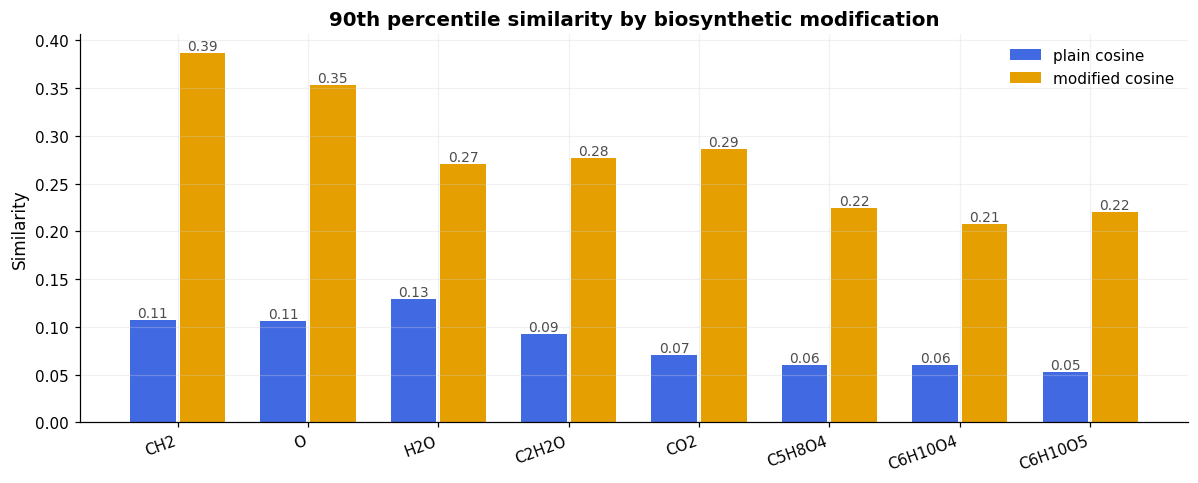

In [89]:
sweep_rows = []
for delta_name, delta in BIOSYNTHETIC_DELTAS.items():
    sweep_rng = np.random.default_rng(RANDOM_STATE)
    positions = sweep_rng.choice(len(index_meta), 2_000, replace=False)
    plain_scores, shifted_scores = [], []

    for position in positions:
        low, high = candidate_window(index_masses[position] + delta, PPM_TOLERANCE)
        for partner in range(low, high):
            if index_keys[partner] == index_keys[position]:
                continue
            if index_modes[partner] != index_modes[position]:
                continue
            query_mzs, query_intensities = spectrum_at(partner)
            ref_mzs, ref_intensities = spectrum_at(position)
            plain, _ = similarity_scores(query_mzs, query_intensities, ref_mzs, ref_intensities)
            shifted = modified_cosine(
                query_mzs, query_intensities, ref_mzs, ref_intensities, delta
            )
            plain_scores.append(plain)
            shifted_scores.append(shifted)
            break

    if not plain_scores:
        continue
    plain_array = np.array(plain_scores)
    shifted_array = np.array(shifted_scores)
    rescued_mask = (plain_array < 0.20) & (shifted_array >= 0.50)
    sweep_rows.append({
        'delta': delta_name.split(',')[0],
        'mass': delta,
        'pairs': len(plain_array),
        'plain_90th': np.percentile(plain_array, 90),
        'modified_90th': np.percentile(shifted_array, 90),
        'rescued': int(rescued_mask.sum()),
        'rescued_pct': rescued_mask.mean(),
    })

delta_sweep = pd.DataFrame(sweep_rows).set_index('delta')

print('🔀 Modified cosine across biosynthetic deltas')
print(f'   Sample: 2,000 index spectra per delta, same seed so the sample is comparable')
print()
print(delta_sweep)

fig, ax = plt.subplots(figsize=(11, 4.5))
positions = np.arange(len(delta_sweep))
width = 0.38
for offset, (column, color, label) in enumerate([
    ('plain_90th', ROYAL_BLUE, 'plain cosine'),
    ('modified_90th', AMBER, 'modified cosine'),
]):
    bars = ax.bar(positions + (offset - 0.5) * width, delta_sweep[column], width * 0.92,
                  color=color, label=label)
    for bar, value in zip(bars, delta_sweep[column]):
        ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.2f}',
                ha='center', va='bottom', fontsize=9, color=DARK_GRAY)
ax.set_xticks(positions)
ax.set_xticklabels(delta_sweep.index, rotation=20, ha='right')
ax.set_title('90th percentile similarity by biosynthetic modification')
ax.set_ylabel('Similarity')
ax.legend()

plt.tight_layout()
plt.show()

### **Section 13: A candidate structure database**

Analog matching identifies that an unknown resembles a known molecule offset by some mass. Converting that into a submission requires an actual structure at the unknown's mass, which means a pool of candidates far larger than the structures carrying usable spectra.

Two sources supply it. The training file contributes 274,771 distinct structures that survive the mass filter, most with no spectra worth indexing but every one a legitimate candidate. COCONUT, the open collection of natural products, supplies a further 332,681 absent from the training file entirely. That second source matters because the competition defines a class 2 molecule as one whose structure exists in PubChem or COCONUT rather than one present in the training data, and an earlier submission built on the training structures alone scored slightly below a plain library search.

Neutral mass is derived from the `molecular_formula` column by summing monoisotopic atomic masses rather than computed with RDKit. This is exact arithmetic, and unlike RDKit it remains available during the internet-disabled submission run.

1. Load every distinct structure in the training file with its formula.
2. Add COCONUT structures not already present, matched on InChIKey first block.
3. Restrict to the mass range the test set can contain.
4. Validate the formula parser against RDKit masses for the overlapping structures.
5. Sort by mass and cache, so candidate lookup is a binary search.

In [90]:
MONOISOTOPIC = {
    'H': 1.00782503, 'D': 2.01410178, 'B': 11.00930550, 'C': 12.00000000,
    'N': 14.00307401, 'O': 15.99491462, 'F': 18.99840320, 'Na': 22.98976928,
    'Mg': 23.98504170, 'Si': 27.97692653, 'P': 30.97376151, 'S': 31.97207069,
    'Cl': 34.96885271, 'K': 38.96370649, 'Ca': 39.96259086, 'Mn': 54.93804510,
    'Fe': 55.93493750, 'Co': 58.93319500, 'Ni': 57.93534290, 'Cu': 62.92959750,
    'Zn': 63.92914220, 'As': 74.92159650, 'Se': 79.91652180, 'Br': 78.91833760,
    'I': 126.90447300, 'Hg': 201.97064340,
}
FORMULA_PATTERN = re.compile(r'([A-Z][a-z]?)(\d*)')
MASS_FLOOR, MASS_CEILING = 150.0, 1_200.0
STRUCTURE_DB_CACHE = cache_path('structure_database_coconut.parquet')


def formula_to_mass(formula):
    '''Monoisotopic mass of a molecular formula, by summing atomic masses. No chemistry library needed.'''
    if not isinstance(formula, str) or not formula:
        return np.nan
    total, consumed = 0.0, 0
    for element, count in FORMULA_PATTERN.findall(formula):
        if element not in MONOISOTOPIC:
            return np.nan
        total += MONOISOTOPIC[element] * (int(count) if count else 1)
        consumed += len(element) + len(count)
    return total if consumed == len(formula) else np.nan


if STRUCTURE_DB_CACHE.exists():
    structure_db = pd.read_parquet(STRUCTURE_DB_CACHE)
    mirror_to_working(STRUCTURE_DB_CACHE)
    print(f'💾 Loaded cached structure database: {len(structure_db):,}')
else:
    started = time.time()
    training_structures = (
        load_train(columns=['normalized_smiles', 'inchikey14', 'molecular_formula'])
        .drop_duplicates('normalized_smiles')
        .reset_index(drop=True)
    )
    training_structures['formula_mass'] = [
        formula_to_mass(formula) for formula in training_structures['molecular_formula']
    ]
    training_structures['source'] = 'train'
    print(f'   ⏳ training structures: {len(training_structures):,}')

    coconut_path = next((path for path in INPUT_ROOT.rglob('COCONUT4MetFrag*.csv')), None)
    frames = [training_structures]
    if coconut_path is not None:
        coconut = pd.read_csv(
            coconut_path, usecols=['molecular_formula', 'clean_smiles', 'inchikey']
        ).rename(columns={'clean_smiles': 'normalized_smiles'})
        coconut['inchikey14'] = coconut['inchikey'].astype(str).str.split('-').str[0]
        coconut['formula_mass'] = [
            formula_to_mass(formula) for formula in coconut['molecular_formula']
        ]
        coconut = coconut[
            coconut['formula_mass'].notna()
            & ~coconut['inchikey14'].isin(set(training_structures['inchikey14']))
        ].drop_duplicates('inchikey14')
        coconut['source'] = 'coconut'
        frames.append(coconut[['normalized_smiles', 'inchikey14', 'molecular_formula',
                               'formula_mass', 'source']])
        print(f'   ⏳ coconut structures added: {len(coconut):,}')

    structure_db = pd.concat(frames, ignore_index=True)
    structure_db = (
        structure_db[
            structure_db['formula_mass'].between(MASS_FLOOR, MASS_CEILING)
        ]
        .sort_values('formula_mass', kind='stable')
        .reset_index(drop=True)
    )
    structure_db.to_parquet(STRUCTURE_DB_CACHE, index=False)
    print(f'💾 Structure database built in {(time.time() - started) / 60:,.1f} min')

checkable = structure_db.merge(
    mass_df[['normalized_smiles', 'exact_mass']], on='normalized_smiles', how='inner'
)
deviation = (checkable['formula_mass'] - checkable['exact_mass']).abs()
db_masses = structure_db['formula_mass'].to_numpy()
by_source = structure_db['source'].value_counts()

print()
print('🗃️ Candidate structure database')
print(f'   Structures: {len(structure_db):,}')
for source, count in by_source.items():
    print(f'      {source}: {count:,}')
print(f'   Mass range: {db_masses.min():,.1f} to {db_masses.max():,.1f} Da')
print(f'   With spectra in the index: {index_meta["canonical_key14"].nunique():,}')
print()
print(f'   Parser validation against RDKit on {len(checkable):,} overlapping structures')
print(f'      Median absolute deviation: {deviation.median():,.8f} Da')
print(f'      Disagreements above 0.001 Da: {int((deviation > 0.001).sum()):,}')

💾 Loaded cached structure database: 607,452

🗃️ Candidate structure database
   Structures: 607,452
      coconut: 332,681
      train: 274,771
   Mass range: 150.0 to 1,199.9 Da
   With spectra in the index: 61,022

   Parser validation against RDKit on 63,911 overlapping structures
      Median absolute deviation: 0.00000006 Da
      Disagreements above 0.001 Da: 20


#### **Where the formula and the structure disagree**

Twenty-one structures produce a formula-derived mass that differs from the RDKit-computed mass by more than a thousandth of a Dalton. Every one carries an explicit isotope label, and every deviation is an exact multiple of an isotope mass difference: deuterium exceeds hydrogen by 1.00628 Da, and the observed gaps are one, three, four, five, seven and eight times that value, alongside a chlorine-37 and a nitrogen-15 substitution.

These are isotopically labeled internal standards, spiked into samples so they behave like the target analyte while sitting at a distinguishable mass. The `molecular_formula` column describes the unlabeled compound while the SMILES carries the labels, so the two disagree by design.

The formula-derived mass is the more useful of the two here. The competition's matching key is the first block of the InChIKey, which encodes connectivity only, with isotopic composition relegated to the second block. A labeled compound and its unlabeled parent therefore share a key, which the check below confirms directly. Indexing these at the unlabeled mass is correct, because that is the mass a real spectrum of the compound would carry.

In [91]:
if RDKIT_AVAILABLE:
    suspect = checkable.assign(deviation=deviation).nlargest(21, 'deviation').copy()
    suspect['has_dot'] = suspect['normalized_smiles'].str.contains('.', regex=False)
    suspect['has_charge'] = suspect['normalized_smiles'].str.contains(r'[+-]\]', regex=True)
    suspect['has_isotope'] = suspect['normalized_smiles'].str.contains(r'\[\d+[A-Z]', regex=True)
    suspect['smiles_preview'] = suspect['normalized_smiles'].str.slice(0, 44)

    print('🔎 Structures where the formula and the SMILES disagree')
    print(f'   Multi-component SMILES containing a dot: {int(suspect["has_dot"].sum()):,} of {len(suspect):,}')
    print(f'   Carrying a formal charge: {int(suspect["has_charge"].sum()):,}')
    print(f'   Carrying an isotope label: {int(suspect["has_isotope"].sum()):,}')
    print()
    print(
        suspect[['molecular_formula', 'formula_mass', 'exact_mass', 'deviation', 'smiles_preview']]
        .to_string(index=False)
    )
else:
    print('⏭️ Formula validation requires RDKit')

🔎 Structures where the formula and the SMILES disagree
   Multi-component SMILES containing a dot: 0 of 21
   Carrying a formal charge: 2
   Carrying an isotope label: 20

molecular_formula  formula_mass  exact_mass  deviation                               smiles_preview
         C20H32O2      304.2402    312.2904     8.0502 [2H]C(CCCCC)=C([2H])CC([2H])=C([2H])CC([2H])
       C42H79O13P      822.5258    829.5698     7.0439 [2H]C([2H])([2H])C([2H])([2H])C([2H])([2H])C
         C51H96O6      804.7207    809.7521     5.0314 [2H]C([2H])(OC(=O)CCCCCCCCCCCCCC)C([2H])(OC(
         C47H88O6      748.6581    753.6895     5.0314 [2H]C([2H])(OC(=O)CCCCCCCCCCCCC)C([2H])(OC(=
         C35H68O5      568.5067    573.5381     5.0314 [2H]C([2H])(OC(=O)CCCCCCCCCCCCCCC)C([2H])(O)
         C43H68O5      664.5067    669.5381     5.0314 [2H]C([2H])(OC(=O)CCCC=CCC=CCC=CCC=CCCCCC)C(
         C43H64O5      660.4754    665.5068     5.0314 [2H]C([2H])(OC(=O)CCCC=CCC=CCC=CCC=CCC=CCC)C
         C33H64O5      540.4

In [92]:
if RDKIT_AVAILABLE:
    pairs = [
        ('caffeine-d3', '[2H]C([2H])([2H])n1c(=O)c2c(ncn2C)n(C)c1=O', 'Cn1c(=O)c2c(ncn2C)n(C)c1=O'),
        ('threonine-15N', 'CC(O)C([15NH2])C(=O)O', 'CC(O)C(N)C(=O)O'),
    ]

    print('🏷️ Does the scorer distinguish isotope labels?')
    for label, tagged, plain in pairs:
        tagged_key = smiles_to_inchikey14(tagged)
        plain_key = smiles_to_inchikey14(plain)
        print(f'   {label}: {tagged_key} vs {plain_key} | same: {tagged_key == plain_key}')
else:
    print('⏭️ Isotope check requires RDKit')

🏷️ Does the scorer distinguish isotope labels?
   caffeine-d3: RYYVLZVUVIJVGH vs RYYVLZVUVIJVGH | same: True
   threonine-15N: AYFVYJQAPQTCCC vs AYFVYJQAPQTCCC | same: True


### **Section 14: Molecular fingerprints for candidate ranking**

Analog matching produces a mass and a reference molecule the unknown resembles. Ranking the candidates at that mass requires a numeric representation of structure, and the choice of representation turns out to matter more than it first appears.

A Morgan fingerprint records the substructures present within a given radius of each atom. Stored as a bit vector, it records only whether each substructure occurs. That is fatal for the relationship most common in this data: an eleven carbon chain and a twelve carbon chain contain exactly the same substructures, since every interior CH2 has an identical environment, so the extra carbon adds no new bit and the two molecules receive identical fingerprints. Tested directly, a homolog pair scored 1.0000 against each other, meaning the representation could not distinguish them at all.

Counting each substructure rather than merely noting it restores the distinction, at the cost of storing bytes instead of bits. Similarity becomes the sum of elementwise minimums over the sum of elementwise maximums, which reduces to the ordinary Tanimoto coefficient when all counts are zero or one.

1. Compute a 2048-feature Morgan count fingerprint for every candidate structure.
2. Store as bytes, clipped at 255, and cache.
3. Verify that identical molecules score 1.0, that the homolog pair now separates, and that unrelated molecules stay near zero.

In [93]:
FINGERPRINT_FEATURES = 2048
FINGERPRINT_CACHE = cache_path('structure_fingerprints_coconut.npz')

morgan_generator = None
if RDKIT_AVAILABLE:
    morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2, fpSize=FINGERPRINT_FEATURES
    )


def tanimoto(counts_a, counts_b):
    '''Count-aware Tanimoto: shared substructure occurrences over total occurrences.'''
    denominator = int(np.maximum(counts_a, counts_b).sum())
    if denominator == 0:
        return 0.0
    return int(np.minimum(counts_a, counts_b).sum()) / denominator


def fingerprint_of(smiles):
    '''Morgan count fingerprint for one SMILES as bytes, or None if it will not parse.'''
    if morgan_generator is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    counts = morgan_generator.GetCountFingerprintAsNumPy(mol)
    return np.clip(counts, 0, 255).astype(np.uint8)


if FINGERPRINT_CACHE.exists():
    fingerprints = np.load(FINGERPRINT_CACHE)['fingerprints']
    mirror_to_working(FINGERPRINT_CACHE)
    print(f'💾 Loaded cached fingerprints: {fingerprints.shape[0]:,}')
elif RDKIT_AVAILABLE:
    started = time.time()
    total = len(structure_db)
    fingerprints = np.zeros((total, FINGERPRINT_FEATURES), dtype=np.uint8)
    failures = 0
    for position, smiles in enumerate(structure_db['normalized_smiles']):
        counts = fingerprint_of(smiles)
        if counts is None:
            failures += 1
        else:
            fingerprints[position] = counts
        if (position + 1) % 50_000 == 0 or position + 1 == total:
            print(f'   ⏳ {position + 1:,} of {total:,} | {(time.time() - started) / 60:,.1f} min elapsed')
    np.savez_compressed(FINGERPRINT_CACHE, fingerprints=fingerprints)
    print(f'💾 Fingerprints computed in {(time.time() - started) / 60:,.1f} min | parse failures: {failures:,}')
else:
    fingerprints = None
    print('⏭️ Fingerprints require RDKit and no cache is attached')

if fingerprints is not None and RDKIT_AVAILABLE:
    checks = [
        ('a molecule against itself',
         'CCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1',
         'CCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1'),
        ('the homolog pair, eleven carbons against twelve',
         'CCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1',
         'CCCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1'),
        ('the same reference against a three carbon jump',
         'CCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1',
         'CCCCCCCCCCCCCCNc1ccc(C(=O)NCC(=O)O)cc1'),
        ('caffeine against threonine',
         'Cn1c(=O)c2c(ncn2C)n(C)c1=O',
         'CC(O)C(N)C(=O)O'),
    ]
    covered = int((fingerprints.any(axis=1)).sum())

    print()
    print('🧷 Fingerprint verification')
    print(f'   Structures with a fingerprint: {covered:,} of {len(structure_db):,}')
    print(f'   Storage: {fingerprints.nbytes / (1024 ** 2):,.0f} MB')
    for label, left, right in checks:
        print(f'   {label}: {tanimoto(fingerprint_of(left), fingerprint_of(right)):,.4f}')

💾 Loaded cached fingerprints: 607,452

🧷 Fingerprint verification
   Structures with a fingerprint: 606,769 of 607,452
   Storage: 1,186 MB
   a molecule against itself: 1.0000
   the homolog pair, eleven carbons against twelve: 0.9595
   the same reference against a three carbon jump: 0.8875
   caffeine against threonine: 0.0566


#### **Cache integrity**

The fingerprint matrix is addressed by row position in the structure database, not by key. A database rebuilt or extended after the fingerprints were cached would therefore misalign every lookup, silently returning a different molecule's fingerprint rather than raising an error. Both artifacts are cached separately and loaded independently, so the two row counts are compared directly before anything depends on them.

In [94]:
# The fingerprint matrix is indexed by structure database row position, so a database
# rebuilt after the fingerprints were cached misaligns every lookup without raising.
print('🔍 Cache alignment check')
db_rows = len(pd.read_parquet(STRUCTURE_DB_CACHE, columns=['inchikey14']))
print(f'   Structure database rows on disk: {db_rows:,}')
with np.load(FINGERPRINT_CACHE) as bundle:
    for key in bundle.files:
        print(f'   Fingerprint array {key}: shape {bundle[key].shape}')
print(f'   Live database rows in memory: {len(structure_db):,}')

🔍 Cache alignment check
   Structure database rows on disk: 607,452
   Fingerprint array fingerprints: shape (607452, 2048)
   Live database rows in memory: 607,452


### **Section 15: Analog propagation**

Every piece now exists. Mass-shifted matching finds a reference molecule the unknown resembles at a biosynthetic offset. The candidate database supplies real structures at the unknown's own mass. Count fingerprints rank those candidates by how closely each resembles the matched reference.

The held-out condition removes validation structures from the spectral index while leaving them in the candidate database, which is exactly the class 2 situation the competition describes: no public spectra for the molecule, but the structure is known to chemistry. Section 11 measured a library search at 0.0000 here by construction. This section asks whether analog propagation can move that.

Water is excluded from the delta set. The delta sweep in Section 12 showed it carries the highest plain cosine of any offset while gaining least from the shift, because water loss is a universal fragmentation pathway rather than a sign of kinship.

1. For each query spectrum, search mass windows offset by each biosynthetic delta in both directions.
2. Score those with the modified cosine, which permits the shifted match.
3. For each analog above threshold, retrieve candidate structures at the query's own mass.
4. Rank by the product of spectral evidence and structural similarity to the matched analog.

In [95]:
ANALOG_DELTAS = {
    name: value for name, value in BIOSYNTHETIC_DELTAS.items()
    if not name.startswith('H2O')
}
ANALOG_THRESHOLD = 0.50

db_smiles = structure_db['normalized_smiles'].to_numpy()
db_keys = structure_db['inchikey14'].to_numpy()
db_mass_array = structure_db['formula_mass'].to_numpy()
structure_position = {smiles: position for position, smiles in enumerate(db_smiles)}


def structure_window(mass, ppm):
    '''Candidate database positions within tolerance of a mass.'''
    delta = mass * ppm / 1_000_000
    return (
        int(np.searchsorted(db_mass_array, mass - delta, side='left')),
        int(np.searchsorted(db_mass_array, mass + delta, side='right')),
    )


def analog_candidates(query_mzs, query_intensities, query_mass, query_mode, blocked):
    '''Structures reached by matching an analog at a biosynthetic offset and propagating.'''
    scored = {}
    cand_low, cand_high = structure_window(query_mass, PPM_TOLERANCE)
    if cand_high <= cand_low:
        return scored

    anchors = []
    for delta in ANALOG_DELTAS.values():
        for shift in (delta, -delta):
            reference_mass = query_mass - shift
            low, high = candidate_window(reference_mass, PPM_TOLERANCE)
            for position in range(low, high):
                if index_modes[position] != query_mode:
                    continue
                if index_keys[position] in blocked:
                    continue
                evidence = modified_cosine(
                    query_mzs, query_intensities, *spectrum_at(position), shift
                )
                if evidence < ANALOG_THRESHOLD:
                    continue
                anchor = structure_position.get(index_smiles[position])
                if anchor is None:
                    continue
                anchors.append((evidence, anchor))

    anchors.sort(key=lambda item: item[0], reverse=True)
    for evidence, anchor in anchors[:MAX_ANCHORS]:
        anchor_fingerprint = fingerprints[anchor]
        for candidate in range(cand_low, cand_high):
            combined = evidence * tanimoto(fingerprints[candidate], anchor_fingerprint)
            key = db_keys[candidate]
            if combined > scored.get(key, (0.0, ''))[0]:
                scored[key] = (combined, db_smiles[candidate])
    return scored
    

def predict_by_analogy(frame, group_column, blocked=frozenset(), label='queries'):
    '''Ranked SMILES per molecule using analog propagation alone.'''
    predictions = {}
    started = time.time()
    groups = list(frame.groupby(group_column))
    for position, (molecule, rows) in enumerate(groups, start=1):
        fused = {}
        for row in rows.itertuples():
            query_mass = neutral_mass(row.precursor_mz, row.adduct)
            if not np.isfinite(query_mass) or row.clean_n_peaks < 5:
                continue
            for key, (score, smiles) in analog_candidates(
                row.clean_mzs, row.clean_intensities, query_mass, row.ionization_mode, blocked
            ).items():
                if score > fused.get(key, (0.0, ''))[0]:
                    fused[key] = (score, smiles)
        ranked = sorted(fused.items(), key=lambda item: item[1][0], reverse=True)[:TOP_K]
        predictions[molecule] = [smiles for _, (_, smiles) in ranked]
        if position % 50 == 0 or position == len(groups):
            print(f'   ⏳ {label}: {position:,} of {len(groups):,} | {time.time() - started:,.0f}s')
    return predictions


if RDKIT_AVAILABLE and validation_answers:
    analog_novel = predict_by_analogy(
        validation_clean, 'inchikey14', blocked=held_out, label='analog, held-out'
    )
    analog_mrr = mean_reciprocal_rank(analog_novel, validation_answers)
    reached = sum(1 for candidates in analog_novel.values() if candidates)
    hit = sum(
        1 for molecule, candidates in analog_novel.items()
        if any(smiles_to_inchikey14(s) == validation_answers[molecule] for s in candidates)
    )

    print()
    print('🧬 Analog propagation, structure removed from the spectral index')
    print(f'   Molecules receiving any candidate: {reached:,} of {len(validation_answers):,}')
    print(f'   Molecules whose correct answer appears in the top {TOP_K}: {hit:,}')
    print(f'   MRR@25: {analog_mrr:,.4f}')
    print(f'   Library search on the same condition: 0.0000')
else:
    print('⏭️ Analog evaluation requires RDKit and answer keys')

   ⏳ analog, held-out: 50 of 250 | 14s
   ⏳ analog, held-out: 100 of 250 | 30s
   ⏳ analog, held-out: 150 of 250 | 52s
   ⏳ analog, held-out: 200 of 250 | 70s
   ⏳ analog, held-out: 250 of 250 | 85s

🧬 Analog propagation, structure removed from the spectral index
   Molecules receiving any candidate: 224 of 250
   Molecules whose correct answer appears in the top 25: 206
   MRR@25: 0.5117
   Library search on the same condition: 0.0000


#### **The control: what the mass window alone is worth**

Every result in this section needs a floor to be measured against, and the honest floor is not zero. The precursor mass alone narrows 607,452 structures to a few dozen, and filling 25 slots from that window in database order already scores something. A claim that spectral evidence helps has to clear this number rather than clear zero.

The control also exposes the shape of the problem. When a window holds more candidates than there are slots, which is the usual case here, retrieval is no longer the difficulty. The correct structure is already in hand for most molecules, and the whole remaining task is deciding which of the candidates at that mass it is.

In [96]:
def mass_only_predictions(frame, group_column, label='mass only'):
    '''Control: candidates from the mass window alone, no spectral evidence of any kind.'''
    predictions = {}
    groups = list(frame.groupby(group_column))
    for molecule, rows in groups:
        pool = {}
        for row in rows.itertuples():
            query_mass = neutral_mass(row.precursor_mz, row.adduct)
            if not np.isfinite(query_mass):
                continue
            low, high = structure_window(query_mass, PPM_TOLERANCE)
            for candidate in range(low, high):
                pool.setdefault(db_keys[candidate], db_smiles[candidate])
        predictions[molecule] = list(pool.values())[:TOP_K]
    return predictions


if RDKIT_AVAILABLE and validation_answers:
    window_sizes = []
    for row in validation_clean.itertuples():
        query_mass = neutral_mass(row.precursor_mz, row.adduct)
        if np.isfinite(query_mass):
            low, high = structure_window(query_mass, PPM_TOLERANCE)
            window_sizes.append(high - low)
    window_sizes = np.array(window_sizes)

    control = mass_only_predictions(validation_clean, 'inchikey14')
    control_mrr = mean_reciprocal_rank(control, validation_answers)
    control_hit = sum(
        1 for molecule, candidates in control.items()
        if any(smiles_to_inchikey14(s) == validation_answers[molecule] for s in candidates)
    )

    print('🎛️ Control: mass window with no spectral evidence')
    print(f'   Candidates per query window: median {np.median(window_sizes):,.0f} | 90th {np.percentile(window_sizes, 90):,.0f} | max {window_sizes.max():,}')
    print(f'   Windows returning 25 or fewer: {(window_sizes <= TOP_K).mean():.1%}')
    print(f'   Correct answer in the top {TOP_K}: {control_hit:,} of {len(validation_answers):,}')
    print(f'   MRR@25: {control_mrr:,.4f}')
else:
    print('⏭️ Mass-only control requires RDKit and answer keys')

🎛️ Control: mass window with no spectral evidence
   Candidates per query window: median 62 | 90th 209 | max 464
   Windows returning 25 or fewer: 21.2%
   Correct answer in the top 25: 203 of 250
   MRR@25: 0.2560


#### **How many anchors does a query find?**

Analog propagation keeps, for each candidate structure, the highest product of spectral evidence and structural similarity across every anchor it found. Whether that rule is starved or saturated depends on how many anchors a typical query actually locates, which the enumerated delta set makes no promises about. The count also bounds what widening that set could achieve: if most queries already find plenty, then the molecules receiving nothing are failing for some other reason.

In [97]:
if RDKIT_AVAILABLE and validation_answers:
    per_delta = Counter()
    anchors_per_molecule = Counter()
    started = time.time()

    for position_index, (molecule, rows) in enumerate(validation_clean.groupby('inchikey14'), start=1):
        for row in rows.itertuples():
            query_mass = neutral_mass(row.precursor_mz, row.adduct)
            if not np.isfinite(query_mass) or row.clean_n_peaks < 5:
                continue
            for name, delta in ANALOG_DELTAS.items():
                for shift in (delta, -delta):
                    low, high = candidate_window(query_mass - shift, PPM_TOLERANCE)
                    for position in range(low, high):
                        if index_modes[position] != row.ionization_mode:
                            continue
                        if index_keys[position] in held_out:
                            continue
                        evidence = modified_cosine(
                            row.clean_mzs, row.clean_intensities, *spectrum_at(position), shift
                        )
                        if evidence >= ANALOG_THRESHOLD:
                            per_delta[name] += 1
                            anchors_per_molecule[molecule] += 1
        if position_index % 50 == 0:
            print(f'   ⏳ anchors: {position_index:,} of 250 | {time.time() - started:,.0f}s')

    without = 250 - len(anchors_per_molecule)
    counts = np.array(list(anchors_per_molecule.values()))

    print()
    print('⚓ Anchor supply under the enumerated delta set')
    print(f'   Molecules finding no anchor at all: {without:,} of 250')
    print(f'   Anchors per molecule that finds any: median {np.median(counts):,.0f} | 90th {np.percentile(counts, 90):,.0f}')
    print()
    print('   Anchors contributed by each delta')
    for name, total in per_delta.most_common():
        print(f'      {name:<16} {total:,}')
else:
    print('⏭️ Anchor diagnostic requires RDKit and answer keys')

   ⏳ anchors: 50 of 250 | 13s
   ⏳ anchors: 100 of 250 | 28s
   ⏳ anchors: 150 of 250 | 48s
   ⏳ anchors: 200 of 250 | 65s
   ⏳ anchors: 250 of 250 | 78s

⚓ Anchor supply under the enumerated delta set
   Molecules finding no anchor at all: 21 of 250
   Anchors per molecule that finds any: median 85 | 90th 639

   Anchors contributed by each delta
      O, hydroxylation 22,970
      CH2, methylation or chain extension 14,757
      C6H10O5, hexose  6,297
      C2H2O, acetylation 3,793
      C6H10O4, deoxyhexose 3,357
      CO2              3,005
      C5H8O4, pentose  2,538


#### **How many anchors are worth keeping?**

With anchors abundant rather than scarce, the number retained becomes a parameter rather than a constraint, and one worth testing rather than assuming. The cap is swept from a single best anchor to effectively unlimited, and the uncapped row is included deliberately so that the entire comparison comes from one run rather than being measured against a figure remembered from another.

In [98]:
if RDKIT_AVAILABLE and validation_answers:
    original_max = MAX_ANCHORS
    anchor_results = []
    for cap in (1, 3, 10, 30, 10_000):
        MAX_ANCHORS = cap
        started = time.time()
        predictions = predict_by_analogy(
            validation_clean, 'inchikey14', blocked=held_out, label=f'anchor cap {cap:,}'
        )
        anchor_results.append(
            (cap, mean_reciprocal_rank(predictions, validation_answers), time.time() - started)
        )
    MAX_ANCHORS = original_max

    print()
    print('⚓ Anchor cap sweep, held-out')
    print(f'   {"cap":>7} | {"MRR@25":>8} | {"seconds":>8}')
    for cap, score, elapsed in anchor_results:
        print(f'   {cap:>7,} | {score:>8,.4f} | {elapsed:>8,.0f}')
    print(f'   Cap restored to {MAX_ANCHORS:,}')
else:
    print('⏭️ Anchor sweep requires RDKit and answer keys')

   ⏳ anchor cap 1: 50 of 250 | 12s
   ⏳ anchor cap 1: 100 of 250 | 27s
   ⏳ anchor cap 1: 150 of 250 | 48s
   ⏳ anchor cap 1: 200 of 250 | 64s
   ⏳ anchor cap 1: 250 of 250 | 78s
   ⏳ anchor cap 3: 50 of 250 | 13s
   ⏳ anchor cap 3: 100 of 250 | 28s
   ⏳ anchor cap 3: 150 of 250 | 49s
   ⏳ anchor cap 3: 200 of 250 | 66s
   ⏳ anchor cap 3: 250 of 250 | 80s
   ⏳ anchor cap 10: 50 of 250 | 14s
   ⏳ anchor cap 10: 100 of 250 | 30s
   ⏳ anchor cap 10: 150 of 250 | 53s
   ⏳ anchor cap 10: 200 of 250 | 71s
   ⏳ anchor cap 10: 250 of 250 | 87s
   ⏳ anchor cap 30: 50 of 250 | 17s
   ⏳ anchor cap 30: 100 of 250 | 34s
   ⏳ anchor cap 30: 150 of 250 | 60s
   ⏳ anchor cap 30: 200 of 250 | 80s
   ⏳ anchor cap 30: 250 of 250 | 97s
   ⏳ anchor cap 10,000: 50 of 250 | 24s
   ⏳ anchor cap 10,000: 100 of 250 | 54s
   ⏳ anchor cap 10,000: 150 of 250 | 96s
   ⏳ anchor cap 10,000: 200 of 250 | 130s
   ⏳ anchor cap 10,000: 250 of 250 | 151s

⚓ Anchor cap sweep, held-out
       cap |   MRR@25 |  seconds
     

### **Section 16: Merging the three retrieval paths**

Three mechanisms now produce candidates, each covering a different novelty class. Library search identifies molecules with public reference spectra. Analog propagation reaches molecules absent from the spectral libraries but present in chemical databases. The mass window supplies a floor, since a wrong guess costs nothing beyond the rank it occupies and an empty slot is strictly worse than a poor one.

Their scores are not comparable. A library cosine expresses direct spectral identity, an analog score expresses resemblance to a resemblance, and a mass window candidate carries no spectral evidence whatsoever. Rather than blending them into a single number, candidates are allocated by tier in descending order of confidence, ranked within each tier by that tier's own score. Duplicates are removed across tiers using the structure key, so no slot is spent twice on the same molecule.

1. Collect candidates from all three paths for every spectrum belonging to a molecule.
2. Deduplicate across tiers by structure.
3. Emit in tier order until 25 slots are filled.
4. Evaluate against both validation conditions, with the single-path results from Sections 11 and 15 as the comparison.

In [99]:
def structure_key(smiles):
    '''The candidate database key for a SMILES, so tiers deduplicate against each other.'''
    position = structure_position.get(smiles)
    return db_keys[position] if position is not None else smiles


def merged_candidates(rows, blocked):
    '''Confident library hits, then analog propagation, then weak library hits, then the mass floor.'''
    library, analog, floor = {}, {}, {}

    for row in rows.itertuples():
        query_mass = neutral_mass(row.precursor_mz, row.adduct)
        if not np.isfinite(query_mass) or row.clean_n_peaks < 5:
            continue

        for key, (score, smiles) in score_one_spectrum(
            row.clean_mzs, row.clean_intensities, query_mass,
            row.ionization_mode, PPM_TOLERANCE, blocked,
        ).items():
            if score > library.get(key, (0.0, ''))[0]:
                library[key] = (score, smiles)

        for key, (score, smiles) in analog_candidates(
            row.clean_mzs, row.clean_intensities, query_mass, row.ionization_mode, blocked
        ).items():
            if score > analog.get(key, (0.0, ''))[0]:
                analog[key] = (score, smiles)

        low, high = structure_window(query_mass, PPM_TOLERANCE)
        for candidate in range(low, high):
            proximity = -abs(db_mass_array[candidate] - query_mass)
            key = db_keys[candidate]
            if proximity > floor.get(key, (-np.inf, ''))[0]:
                floor[key] = (proximity, db_smiles[candidate])

    confident = {key: value for key, value in library.items() if value[0] >= LIBRARY_CONFIDENT}
    weak = {key: value for key, value in library.items() if value[0] < LIBRARY_CONFIDENT}

    primary = {}
    for source in (confident, analog):
        for key, value in source.items():
            if value[0] > primary.get(key, (0.0, ''))[0]:
                primary[key] = value

    ordered, seen = [], set()
    for tier in (primary, weak, floor):
        ranked = sorted(tier.items(), key=lambda item: item[1][0], reverse=True)
        for _, (score, smiles) in ranked:
            key = structure_key(smiles)
            if key in seen:
                continue
            seen.add(key)
            ordered.append(smiles)
            if len(ordered) >= TOP_K:
                return ordered
    return ordered


def predict_merged(frame, group_column, blocked=frozenset(), label='queries'):
    '''Ranked SMILES per molecule from all three retrieval paths.'''
    predictions = {}
    started = time.time()
    groups = list(frame.groupby(group_column))
    for position, (molecule, rows) in enumerate(groups, start=1):
        predictions[molecule] = merged_candidates(rows, blocked)
        if position % 50 == 0 or position == len(groups):
            print(f'   ⏳ {label}: {position:,} of {len(groups):,} | {time.time() - started:,.0f}s')
    return predictions


if RDKIT_AVAILABLE and validation_answers:
    library_scores = []
    for _, rows in validation_clean.groupby('inchikey14'):
        for row in rows.itertuples():
            query_mass = neutral_mass(row.precursor_mz, row.adduct)
            if not np.isfinite(query_mass) or row.clean_n_peaks < 5:
                continue
            hits = score_one_spectrum(
                row.clean_mzs, row.clean_intensities, query_mass,
                row.ionization_mode, PPM_TOLERANCE, held_out,
            )
            library_scores.extend(score for score, _ in hits.values())
    library_scores = np.array(library_scores)

    print('🔬 Library hits when the correct answer is blocked')
    print(f'   Hits returned: {len(library_scores):,}')
    if len(library_scores):
        above = (library_scores >= LIBRARY_CONFIDENT).mean()
        print(f'   Median {np.median(library_scores):,.4f} | 90th {np.percentile(library_scores, 90):,.4f}')
        print(f'   Share scoring at or above {LIBRARY_CONFIDENT:,.2f}: {above:.1%}')
    print()

    merged_in_library = predict_merged(validation_clean, 'inchikey14', label='merged, in-library')
    merged_held_out = predict_merged(
        validation_clean, 'inchikey14', blocked=held_out, label='merged, held-out'
    )

    in_library_score = mean_reciprocal_rank(merged_in_library, validation_answers)
    held_out_score = mean_reciprocal_rank(merged_held_out, validation_answers)
    slots = [len(candidates) for candidates in merged_held_out.values()]

    print()
    print('🔗 Merged pipeline, confidence-gated tiers')
    print(f'   Slots filled per molecule: median {np.median(slots):,.0f} | minimum {np.min(slots):,}')
    print()
    print(f'   In-library | gated merge {in_library_score:,.4f}')
    print(f'   Held-out   | gated merge {held_out_score:,.4f}')
else:
    print('⏭️ Merged evaluation requires RDKit and answer keys')

🔬 Library hits when the correct answer is blocked
   Hits returned: 6,009
   Median 0.2553 | 90th 0.7637
   Share scoring at or above 0.95: 1.6%

   ⏳ merged, in-library: 50 of 250 | 19s
   ⏳ merged, in-library: 100 of 250 | 38s
   ⏳ merged, in-library: 150 of 250 | 65s
   ⏳ merged, in-library: 200 of 250 | 89s
   ⏳ merged, in-library: 250 of 250 | 108s
   ⏳ merged, held-out: 50 of 250 | 15s
   ⏳ merged, held-out: 100 of 250 | 32s
   ⏳ merged, held-out: 150 of 250 | 56s
   ⏳ merged, held-out: 200 of 250 | 75s
   ⏳ merged, held-out: 250 of 250 | 92s

🔗 Merged pipeline, confidence-gated tiers
   Slots filled per molecule: median 25 | minimum 0

   In-library | gated merge 0.8473
   Held-out   | gated merge 0.5007


#### **Does library search still earn its place?**

The merged pipeline assumes both retrieval paths contribute, but only half of that assumption has been tested. Held-out validation measures analog propagation with the correct structure removed from the index; the in-library half of the pair was never run. If analog propagation scored near 0.90 with those structures present, library search would be redundant and the tier apparatus unnecessary.

In [100]:
# Ablation: analog propagation with no library tier, on the in-library condition.
# Held-out already measures analog alone at 0.5060. This is the other half of the pair,
# and it decides whether library search is earning its place in the pipeline at all.
if RDKIT_AVAILABLE and validation_answers:
    analog_in_library = predict_by_analogy(validation_clean, 'inchikey14', label='analog, in-library')
    analog_in_library_score = mean_reciprocal_rank(analog_in_library, validation_answers)
    covered = sum(1 for candidates in analog_in_library.values() if candidates)

    print()
    print('🧪 Analog propagation alone, structure present in the spectral index')
    print(f'   Molecules receiving any candidate: {covered:,} of {len(analog_in_library):,}')
    print(f'   MRR@25: {analog_in_library_score:,.4f}')
else:
    print('⏭️ Ablation requires RDKit and answer keys')

   ⏳ analog, in-library: 50 of 250 | 16s
   ⏳ analog, in-library: 100 of 250 | 34s
   ⏳ analog, in-library: 150 of 250 | 58s
   ⏳ analog, in-library: 200 of 250 | 79s
   ⏳ analog, in-library: 250 of 250 | 96s

🧪 Analog propagation alone, structure present in the spectral index
   Molecules receiving any candidate: 225 of 250
   MRR@25: 0.5180


#### **Where to set the confidence gate**

The threshold separating confident library hits from weak ones is the pipeline's regime detector: it decides, without knowing a molecule's novelty class, whether to trust spectral identity or structural analogy. Cost and benefit land in opposite conditions, so neither can be read alone. Raising it protects the held-out case by demoting library hits that are confidently wrong, and damages the in-library case by demoting hits that are merely quietly right.

In [101]:
# Gate sweep. The confidence threshold is the pipeline's regime detector, and its cost and
# benefit land in opposite regimes, so neither can be read without the other.
if RDKIT_AVAILABLE and validation_answers:
    original_gate = LIBRARY_CONFIDENT
    gate_results = []
    for gate in (0.70, 0.85, 0.95):
        LIBRARY_CONFIDENT = gate
        in_library = mean_reciprocal_rank(
            predict_merged(validation_clean, 'inchikey14', label=f'gate {gate:,.2f}, in-library'),
            validation_answers,
        )
        held = mean_reciprocal_rank(
            predict_merged(validation_clean, 'inchikey14', blocked=held_out, label=f'gate {gate:,.2f}, held-out'),
            validation_answers,
        )
        gate_results.append((gate, in_library, held))
    LIBRARY_CONFIDENT = original_gate

    print()
    print('🎚️ Confidence gate sweep')
    print(f'   {"gate":>6} | {"in-library":>10} | {"held-out":>9}')
    for gate, in_library, held in gate_results:
        print(f'   {gate:>6,.2f} | {in_library:>10,.4f} | {held:>9,.4f}')
    print(f'   Gate restored to {LIBRARY_CONFIDENT:,.2f}')
else:
    print('⏭️ Gate sweep requires RDKit and answer keys')

   ⏳ gate 0.70, in-library: 50 of 250 | 19s
   ⏳ gate 0.70, in-library: 100 of 250 | 38s
   ⏳ gate 0.70, in-library: 150 of 250 | 66s
   ⏳ gate 0.70, in-library: 200 of 250 | 89s
   ⏳ gate 0.70, in-library: 250 of 250 | 108s
   ⏳ gate 0.70, held-out: 50 of 250 | 15s
   ⏳ gate 0.70, held-out: 100 of 250 | 32s
   ⏳ gate 0.70, held-out: 150 of 250 | 56s
   ⏳ gate 0.70, held-out: 200 of 250 | 76s
   ⏳ gate 0.70, held-out: 250 of 250 | 93s
   ⏳ gate 0.85, in-library: 50 of 250 | 19s
   ⏳ gate 0.85, in-library: 100 of 250 | 39s
   ⏳ gate 0.85, in-library: 150 of 250 | 66s
   ⏳ gate 0.85, in-library: 200 of 250 | 90s
   ⏳ gate 0.85, in-library: 250 of 250 | 109s
   ⏳ gate 0.85, held-out: 50 of 250 | 15s
   ⏳ gate 0.85, held-out: 100 of 250 | 32s
   ⏳ gate 0.85, held-out: 150 of 250 | 56s
   ⏳ gate 0.85, held-out: 200 of 250 | 75s
   ⏳ gate 0.85, held-out: 250 of 250 | 92s
   ⏳ gate 0.95, in-library: 50 of 250 | 19s
   ⏳ gate 0.95, in-library: 100 of 250 | 39s
   ⏳ gate 0.95, in-library: 150 o

### **Section 17: Generating a submission**

The competition specifies four conditions for a valid submission file, and it is rejected outright if any fail: both columns present, no nulls, no repeated `molecule_id`, and no more than 25 semicolon-separated guesses for any molecule. Three additional checks are added to those four: that the file is not empty, that no SMILES string is blank, and that every test molecule appears.  Since a molecule whose spectra return no candidate would produce a null, a fallback supplies the structures nearest in mass regardless of ionization mode. A wrong guess costs nothing beyond the rank it occupies, so an empty slot is strictly worse than a poor one.

1. Run the pipeline over the test set, grouped by `molecule_id`.
2. Fill any molecule with no candidates using the nearest structures by mass.
3. Assemble the file and verify it against each stated rejection condition before writing.

In [102]:
SUBMISSION_PATH = WORK_DIR / 'submission.csv'


def mass_nearest_candidates(query_mass, limit=TOP_K):
    '''Fallback candidates by mass proximity alone, for queries that retrieve nothing.'''
    position = int(np.searchsorted(index_masses, query_mass))
    low = max(0, position - limit * 6)
    high = min(len(index_masses), position + limit * 6)
    window = np.arange(low, high)
    ordered = window[np.argsort(np.abs(index_masses[window] - query_mass))]
    seen, picks = set(), []
    for slot in ordered:
        key = index_keys[slot]
        if key in seen:
            continue
        seen.add(key)
        picks.append(index_smiles[slot])
        if len(picks) >= limit:
            break
    return picks


test_predictions = predict_merged(test_clean, 'molecule_id', label='test')

query_masses = (
    test_clean.assign(mass=test_clean['precursor_mz'] + test_clean['adduct'].map(ADDUCT_NEUTRAL_OFFSET))
    .groupby('molecule_id')['mass'].median()
)

filled = 0
for molecule_id in test_df['molecule_id'].unique():
    if not test_predictions.get(molecule_id):
        test_predictions[molecule_id] = mass_nearest_candidates(float(query_masses[molecule_id]))
        filled += 1

submission = pd.DataFrame({
    'molecule_id': list(test_predictions.keys()),
    'smiles': [';'.join(candidates[:TOP_K]) for candidates in test_predictions.values()],
})

checks = {
    'both columns present': list(submission.columns) == ['molecule_id', 'smiles'],
    'not empty': len(submission) > 0,
    'no nulls': not submission.isna().any().any(),
    'no empty smiles strings': bool((submission['smiles'].str.len() > 0).all()),
    'no repeated molecule_id': not submission['molecule_id'].duplicated().any(),
    'at most 25 guesses': bool((submission['smiles'].str.count(';') + 1 <= TOP_K).all()),
    'every test molecule present': set(submission['molecule_id']) == set(test_df['molecule_id']),
}

guess_counts = submission['smiles'].str.count(';') + 1
print('📤 Submission')
print(f'   Rows: {len(submission):,} | molecules filled by mass fallback: {filled:,}')
print(f'   Guesses per molecule: median {guess_counts.median():,.0f} | min {guess_counts.min():,} | max {guess_counts.max():,}')
for label, passed in checks.items():
    print(f'   {"✅" if passed else "❌"} {label}')

if all(checks.values()):
    submission.to_csv(SUBMISSION_PATH, index=False)
    print(f'   💾 Written to {SUBMISSION_PATH.name}')
else:
    print('   🚫 Not written, fix the failing checks first')

   ⏳ test: 50 of 400 | 9s
   ⏳ test: 100 of 400 | 15s
   ⏳ test: 150 of 400 | 21s
   ⏳ test: 200 of 400 | 28s
   ⏳ test: 250 of 400 | 36s
   ⏳ test: 300 of 400 | 44s
   ⏳ test: 350 of 400 | 49s
   ⏳ test: 400 of 400 | 56s
📤 Submission
   Rows: 400 | molecules filled by mass fallback: 0
   Guesses per molecule: median 25 | min 3 | max 25
   ✅ both columns present
   ✅ not empty
   ✅ no nulls
   ✅ no empty smiles strings
   ✅ no repeated molecule_id
   ✅ at most 25 guesses
   ✅ every test molecule present
   💾 Written to submission.csv
